In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.manifold import TSNE
import umap
from scipy.stats import chi2_contingency
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr
import numpy as np
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.sentiment import SentimentIntensityAnalyzer






c:\Users\35193\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_excel('DataWithLyricsEmotionChatgpt4.xlsx')
df

,track_id,artists,track_name,popularity,duration_ms,danceability,energy,key,loudness,mode,...,multiple_genres,youtube_id,comments,lyrics,language,duration_min,kmeans_euclidean_clusters,kmeans_cosine_clusters,cleaned_lyrics,emotion_category
0,6RDHOZtqz8iB6xzii7qaey,Ice Nine Kills,Stabbing In The Dark,1.0,276866,0.333,0.943,10,-4.184,0,...,"alternative, metal, metalcore",wGns433H8nA,['Psychotic Perfection !!! I looooove you guys...,[Intro: Spencer Charnas]\nIn calculated silenc...,en,4.614433,0,0,in calculated silence captivated by the violen...,0
1,697M5JB8FDIyRXEXgl1pBZ,Linkin Park,From the Inside,67.0,173933,0.466,0.965,1,-2.597,0,...,"alternative, grunge, metal",YLHpvjrFpe0,['I don’t believe it. I never saw this video o...,[Verse 1: Chester Bennington & Mike Shinoda]\n...,en,2.898883,0,0,"i don't know who to trust, no surprise everyon...",0
2,5yEIpnRU3WQmAWoOMP8ge9,BJ The Chicago Kid,Turnin' Me Up,0.0,269240,0.731,0.790,2,-4.214,1,...,"alternative, soul",KZdJoWm3cHU,"['Love it', '2025🎉💥💥💥💥🔥', '❤', '2024❤', 'Decem...",[Intro]\nPlay it from the top [?]\nLet me get ...,en,4.487333,2,2,play it from the top let me get the track just...,2
3,7DczAzWKf2WOretzrzQOCf,Gojira,Stranded,0.0,269533,0.512,0.879,7,-4.690,0,...,"alternative, death-metal, french, groove, metal",FNdC_3LR2AI,['ustedes son una de las mejores bandas contem...,[Verse 1]\nA growing sickness in the heart\nDe...,en,4.492217,0,0,"a growing sickness in the heart defective, lac...",1
4,62qUTJAM7dZgOebu2qB7QB,Royal & the Serpent,Overwhelmed,0.0,159293,0.804,0.323,0,-11.127,0,...,"alternative, indie-pop",_e7UYTY96Xs,"['oh its this song', ""2:32 when I can't find ...","[Intro]\nTo report suspicious activity, you ca...",en,2.654883,1,1,"to report suspicious activity, you can call 91...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1071,0QjQC8sGqxUkaJFBsJjtGm,John Legend,Conversations in the Dark,60.0,235653,0.361,0.357,8,-8.423,0,...,soul,qUD2GxTeVcI,['Como eu amo essa música ! \nLembro do meu ma...,"[Verse 1]\nTalk, let's have conversations in t...",en,3.927550,1,1,"talk, let's have conversations in the dark wor...",1
1072,3IfQpV2eGtzmw1AxWvjrpw,Omar Apollo,Highlight,1.0,153258,0.781,0.661,0,-5.521,1,...,soul,wuRCXK15wfY,"['I absolutely love this song💙', 'Prosto sam o...",[Verse 1]\nYou are not a stranger\nIt’s been a...,en,2.554300,2,2,you are not a stranger its been a minute since...,1
1073,5BKKy9fIJL5uM9fz1SnqyP,Michael Jackson,Chicago,80.0,245506,0.608,0.756,7,-2.675,0,...,soul,xaYSqjvZjTs,"['Is that Chris Tucker?', 'Absolute cinema', '...","[Verse 1]\nAh, I met her on my way to Chicago\...",en,4.091767,0,2,"ah, i met her on my way to chicago where she w...",1
1074,5Uc8Z0SolIfJAgxl51XOiW,Nina Simone,Lilac Wine,0.0,255305,0.393,0.143,6,-11.977,1,...,soul,o7TuGz5H7kE,"['So moving 😢', 'This song hits different with...",I lost myself on a cool damp night\nGave mysel...,en,4.255083,1,1,i lost myself on a cool damp night gave myself...,1


# Data Exploration of Songs

In [3]:
print("This data set has",df.shape[1],"columns and", df.shape[0],"rows")

This data set has 27 columns and 1076 rows


In [4]:
df.columns

Index(['track_id', 'artists', 'track_name', 'popularity', 'duration_ms',
       'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
       'main_genre', 'multiple_genres', 'youtube_id', 'comments', 'lyrics',
       'language', 'duration_min', 'kmeans_euclidean_clusters',
       'kmeans_cosine_clusters', 'cleaned_lyrics', 'emotion_category'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1076 entries, 0 to 1075
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   track_id                   1076 non-null   object 
 1   artists                    1072 non-null   object 
 2   track_name                 1076 non-null   object 
 3   popularity                 1034 non-null   float64
 4   duration_ms                1076 non-null   int64  
 5   danceability               1076 non-null   float64
 6   energy                     1076 non-null   float64
 7   key                        1076 non-null   int64  
 8   loudness                   1076 non-null   float64
 9   mode                       1076 non-null   int64  
 10  speechiness                1076 non-null   float64
 11  acousticness               1076 non-null   float64
 12  instrumentalness           1076 non-null   float64
 13  liveness                   1076 non-null   float

In [6]:
df.describe(include ='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
track_id,1076,1076,6RDHOZtqz8iB6xzii7qaey,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,1072,662,Avenged Sevenfold,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,1076,1076,Stabbing In The Dark,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,1034.0,NaN,NaN,NaN,37.130561,33.595962,0.0,0.0,48.0,68.0,93.0
duration_ms,1076.0,NaN,NaN,NaN,214345.739777,57882.422613,73534.0,176492.75,206609.5,240901.0,622000.0
danceability,1076.0,NaN,NaN,NaN,0.595081,0.152742,0.132,0.492,0.6025,0.707,0.951
energy,1076.0,NaN,NaN,NaN,0.61885,0.22219,0.0264,0.46375,0.644,0.795,0.997
key,1076.0,NaN,NaN,NaN,5.189591,3.57632,0.0,2.0,5.0,8.0,11.0
loudness,1076.0,NaN,NaN,NaN,-7.119733,3.196172,-21.295,-8.69175,-6.3745,-4.85375,-0.734
mode,1076.0,NaN,NaN,NaN,0.615242,0.486764,0.0,0.0,1.0,1.0,1.0


In [7]:
genre_counts = df['main_genre'].value_counts()
genre_counts

main_genre
alternative    90
blues          90
country        90
dance          90
electronic     90
hip-hop        90
metal          90
rock           90
soul           90
jazz           89
pop            89
r-n-b          88
Name: count, dtype: int64

 Approximately 90 songs from each famous genre have been randomly chosen to represent a variety of emotions.

In [8]:
# Defining Metric and non metric features

features_to_drop = ['track_id', 'artists', 'track_name', 'popularity', 'duration_ms',       
       'main_genre', 'multiple_genres', 'youtube_id', 'comments', 'lyrics',
       'language', 'duration_min', 'kmeans_euclidean_clusters',
       'kmeans_cosine_clusters', 'cleaned_lyrics', 'emotion_category']

features_to_visualize = df.columns.drop(features_to_drop).tolist()

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
import re

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

def analyze_lyrics_eda(df):
    """
    Perform exploratory data analysis on lyrics data
    
    Parameters:
    df: DataFrame with columns ['lyrics', 'main_genre', etc.]
    """
    
    print("=== LYRICS EXPLORATORY DATA ANALYSIS ===\n")
    
    # 1. Basic Statistics
    print("1. BASIC LYRICS STATISTICS")
    print("-" * 40)
    
    # Calculate text metrics
    df['lyrics_length'] = df['lyrics'].str.len()
    df['word_count'] = df['lyrics'].str.split().str.len()
    df['line_count'] = df['lyrics'].str.count('\n') + 1
    df['avg_word_length'] = df['lyrics'].apply(lambda x: np.mean([len(word) for word in str(x).split()]) if pd.notna(x) else 0)
    
    # Display overall statistics
    print(f"Total songs with lyrics: {len(df)}")
    print(f"Average lyrics length (characters): {df['lyrics_length'].mean():.1f}")
    print(f"Average word count: {df['word_count'].mean():.1f}")
    print(f"Average line count: {df['line_count'].mean():.1f}")
    print(f"Average word length: {df['avg_word_length'].mean():.1f}")
    print()
    
    # Descriptive statistics table
    lyrics_stats = df[['lyrics_length', 'word_count', 'line_count', 'avg_word_length']].describe()
    print("Detailed Statistics:")
    print(lyrics_stats.round(2))
    print("\n")
    
    # 2. Genre-based Analysis
    print("2. GENRE-BASED LYRICS ANALYSIS")
    print("-" * 40)
    
    # Calculate genre statistics
    genre_stats = df.groupby('main_genre')[['lyrics_length', 'word_count', 'line_count']].agg({
        'lyrics_length': ['mean', 'std'],
        'word_count': ['mean', 'std'],
        'line_count': ['mean', 'std']
    }).round(2)
    
    print("Average metrics by genre:")
    print(genre_stats)
    print("\n")
    
    # 3. Identify potential anomalies
    print("3. POTENTIAL ANOMALIES")
    print("-" * 40)
    
    # Very short lyrics (potential issues)
    short_lyrics = df[df['word_count'] < 10]
    print(f"Songs with very short lyrics (<10 words): {len(short_lyrics)}")
    if len(short_lyrics) > 0:
        print("Examples:")
        for idx, row in short_lyrics.head(3).iterrows():
            print(f"  - {row.get('artist', 'Unknown')} - {row.get('track_name', 'Unknown')}: {row['word_count']} words")
    
    # Very long lyrics
    long_lyrics = df[df['word_count'] > df['word_count'].quantile(0.95)]
    print(f"\nSongs with very long lyrics (>95th percentile): {len(long_lyrics)}")
    if len(long_lyrics) > 0:
        print("Examples:")
        for idx, row in long_lyrics.head(3).iterrows():
            print(f"  - {row.get('artist', 'Unknown')} - {row.get('track_name', 'Unknown')}: {row['word_count']} words")
    print("\n")
    
    # 4. Create visualizations
    create_lyrics_visualizations(df)
    
    return df

def create_lyrics_visualizations(df):
    """Create visualizations for lyrics analysis"""
    
    # Set up the plotting area
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Lyrics Exploratory Data Analysis', fontsize=16, fontweight='bold')
    
    # 1. Distribution of word counts
    axes[0, 0].hist(df['word_count'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(df['word_count'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df["word_count"].mean():.1f}')
    axes[0, 0].set_xlabel('Word Count')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Word Counts')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Distribution of lyrics length (characters)
    axes[0, 1].hist(df['lyrics_length'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
    axes[0, 1].axvline(df['lyrics_length'].mean(), color='red', linestyle='--', 
                       label=f'Mean: {df["lyrics_length"].mean():.0f}')
    axes[0, 1].set_xlabel('Lyrics Length (Characters)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Lyrics Length')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Average word count by genre
    genre_word_counts = df.groupby('main_genre')['word_count'].mean().sort_values(ascending=True)
    axes[1, 0].barh(range(len(genre_word_counts)), genre_word_counts.values, color='coral')
    axes[1, 0].set_yticks(range(len(genre_word_counts)))
    axes[1, 0].set_yticklabels(genre_word_counts.index)
    axes[1, 0].set_xlabel('Average Word Count')
    axes[1, 0].set_title('Average Word Count by Genre')
    axes[1, 0].grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, v in enumerate(genre_word_counts.values):
        axes[1, 0].text(v + 1, i, f'{v:.0f}', va='center', fontsize=9)
    
    # 4. Average lyrics length by genre
    genre_length = df.groupby('main_genre')['lyrics_length'].mean().sort_values(ascending=True)
    axes[1, 1].barh(range(len(genre_length)), genre_length.values, color='mediumpurple')
    axes[1, 1].set_yticks(range(len(genre_length)))
    axes[1, 1].set_yticklabels(genre_length.index)
    axes[1, 1].set_xlabel('Average Lyrics Length (Characters)')
    axes[1, 1].set_title('Average Lyrics Length by Genre')
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    # Add value labels on bars
    for i, v in enumerate(genre_length.values):
        axes[1, 1].text(v + 20, i, f'{v:.0f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # Create box plots for detailed genre comparison
    create_genre_boxplots(df)

def create_genre_boxplots(df):
    """Create box plots for genre-wise lyrics metrics comparison"""
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Genre-wise Lyrics Metrics Distribution', fontsize=16, fontweight='bold')
    
    # Word count by genre
    sns.boxplot(data=df, x='main_genre', y='word_count', ax=axes[0])
    axes[0].set_title('Word Count Distribution by Genre')
    axes[0].set_xlabel('Genre')
    axes[0].set_ylabel('Word Count')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Lyrics length by genre
    sns.boxplot(data=df, x='main_genre', y='lyrics_length', ax=axes[1])
    axes[1].set_title('Lyrics Length Distribution by Genre')
    axes[1].set_xlabel('Genre')
    axes[1].set_ylabel('Lyrics Length (Characters)')
    axes[1].tick_params(axis='x', rotation=45)
    
    # Line count by genre
    sns.boxplot(data=df, x='main_genre', y='line_count', ax=axes[2])
    axes[2].set_title('Line Count Distribution by Genre')
    axes[2].set_xlabel('Genre')
    axes[2].set_ylabel('Line Count')
    axes[2].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

def identify_outliers(df):
    """Identify and report outliers in lyrics data"""
    
    print("4. OUTLIER ANALYSIS")
    print("-" * 40)
    
    # Calculate IQR for word count
    Q1 = df['word_count'].quantile(0.25)
    Q3 = df['word_count'].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Find outliers
    outliers = df[(df['word_count'] < lower_bound) | (df['word_count'] > upper_bound)]
    
    print(f"Word count outliers (beyond 1.5*IQR): {len(outliers)}")
    print(f"Lower bound: {lower_bound:.1f}, Upper bound: {upper_bound:.1f}")
    
    if len(outliers) > 0:
        print("\nTop 5 longest songs:")
        longest = outliers.nlargest(5, 'word_count')[['main_genre', 'word_count']].copy()
        if 'artist' in df.columns and 'track_name' in df.columns:
            longest = outliers.nlargest(5, 'word_count')[['artist', 'track_name', 'main_genre', 'word_count']]
            for idx, row in longest.iterrows():
                print(f"  {row['artist']} - {row['track_name']} ({row['main_genre']}): {row['word_count']} words")
        else:
            for idx, row in longest.iterrows():
                print(f"  Song from {row['main_genre']}: {row['word_count']} words")
        
        print("\nTop 5 shortest songs:")
        shortest = outliers.nsmallest(5, 'word_count')[['main_genre', 'word_count']].copy()
        if 'artist' in df.columns and 'track_name' in df.columns:
            shortest = outliers.nsmallest(5, 'word_count')[['artist', 'track_name', 'main_genre', 'word_count']]
            for idx, row in shortest.iterrows():
                print(f"  {row['artist']} - {row['track_name']} ({row['main_genre']}): {row['word_count']} words")
        else:
            for idx, row in shortest.iterrows():
                print(f"  Song from {row['main_genre']}: {row['word_count']} words")
    
    print("\n")

# Example usage in Jupyter notebook:
# Just run: df_analyzed = analyze_lyrics_eda(df)
# Then run: identify_outliers(df_analyzed)

# Expected DataFrame structure:
print("To use this code in your Jupyter notebook:")
print("Simply run: df_analyzed = analyze_lyrics_eda(df)")
print("Then run: identify_outliers(df_analyzed)")
print("\nYour DataFrame should have columns: 'lyrics', 'main_genre'")
print("Optional columns: 'artist', 'track_name' (for better labeling)")

To use this code in your Jupyter notebook:
Simply run: df_analyzed = analyze_lyrics_eda(df)
Then run: identify_outliers(df_analyzed)

Your DataFrame should have columns: 'lyrics', 'main_genre'
Optional columns: 'artist', 'track_name' (for better labeling)


=== LYRICS EXPLORATORY DATA ANALYSIS ===

1. BASIC LYRICS STATISTICS
----------------------------------------
Total songs with lyrics: 1076
Average lyrics length (characters): 3420.2
Average word count: 665.0
Average line count: 115.7
Average word length: 4.1

Detailed Statistics:
       lyrics_length  word_count  line_count  avg_word_length
count        1076.00     1076.00     1076.00          1076.00
mean         3420.24      664.98      115.71             4.15
std          1675.11      328.23       45.19             0.34
min           121.00       23.00        4.00             3.05
25%          2272.75      439.00       85.00             3.91
50%          3198.50      623.00      114.00             4.12
75%          4229.50      815.00      142.00             4.32
max         10824.00     2115.00      290.00             6.15


2. GENRE-BASED LYRICS ANALYSIS
----------------------------------------
Average metrics by genre:
            lyrics_length          word_count         line_c

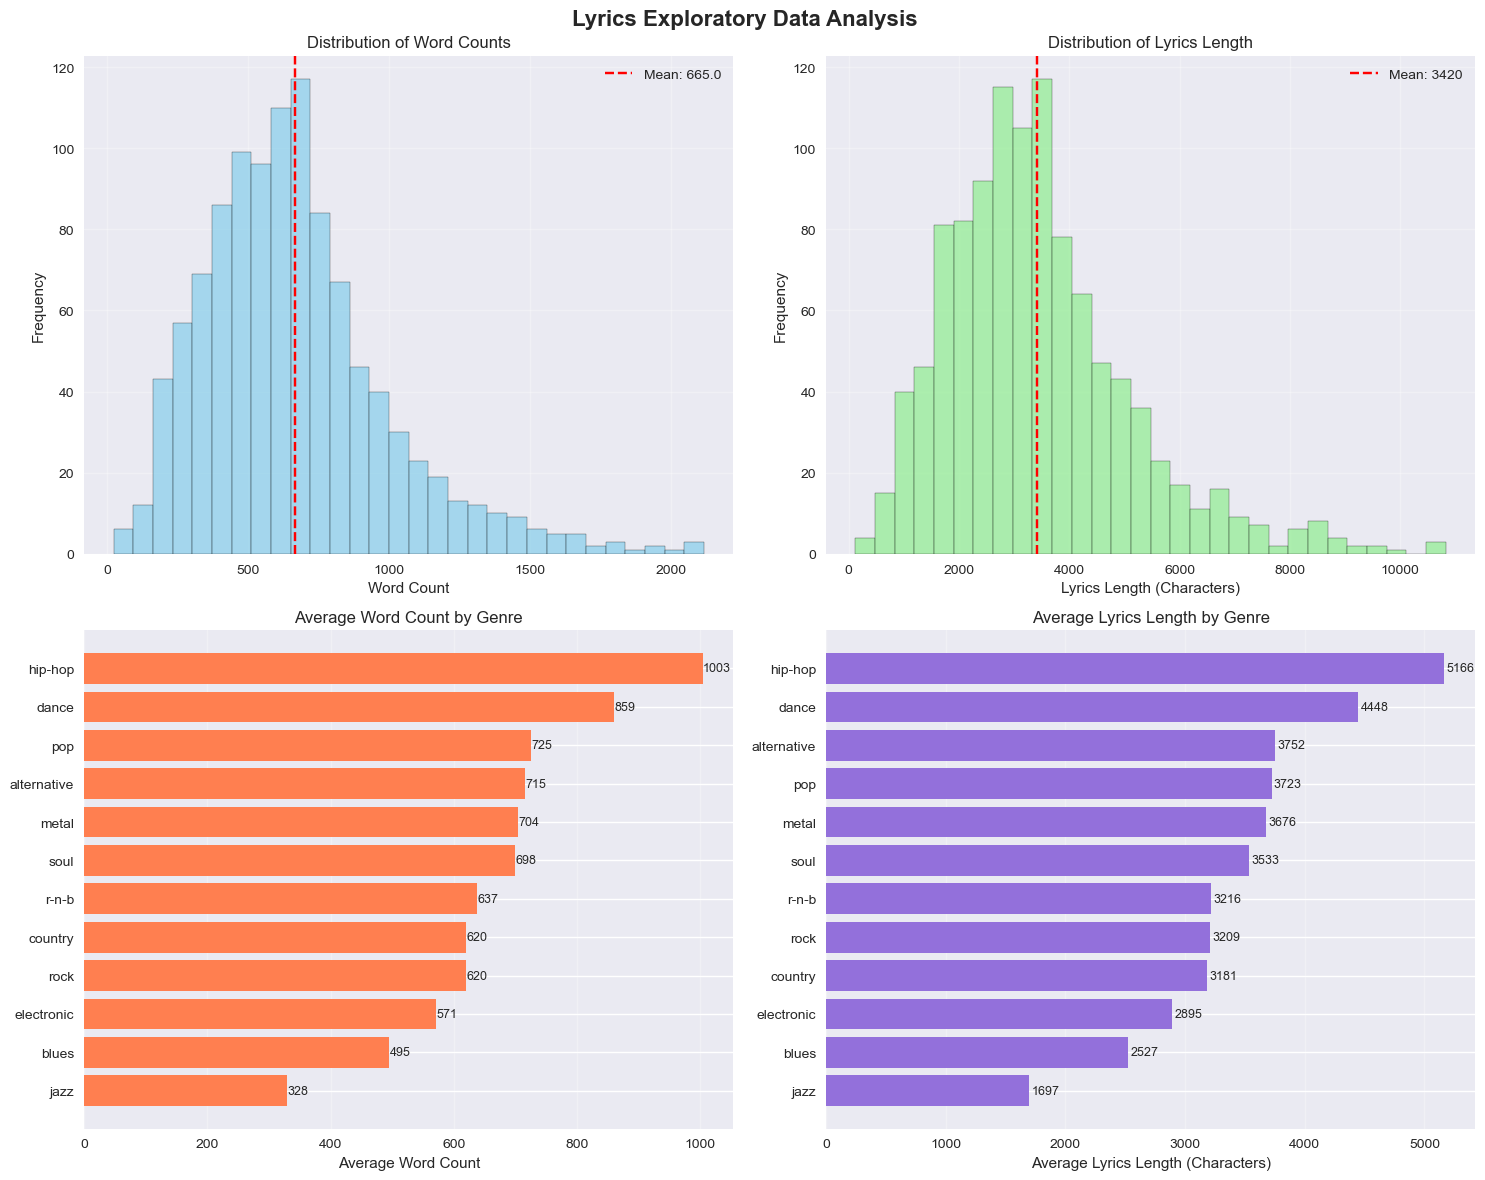

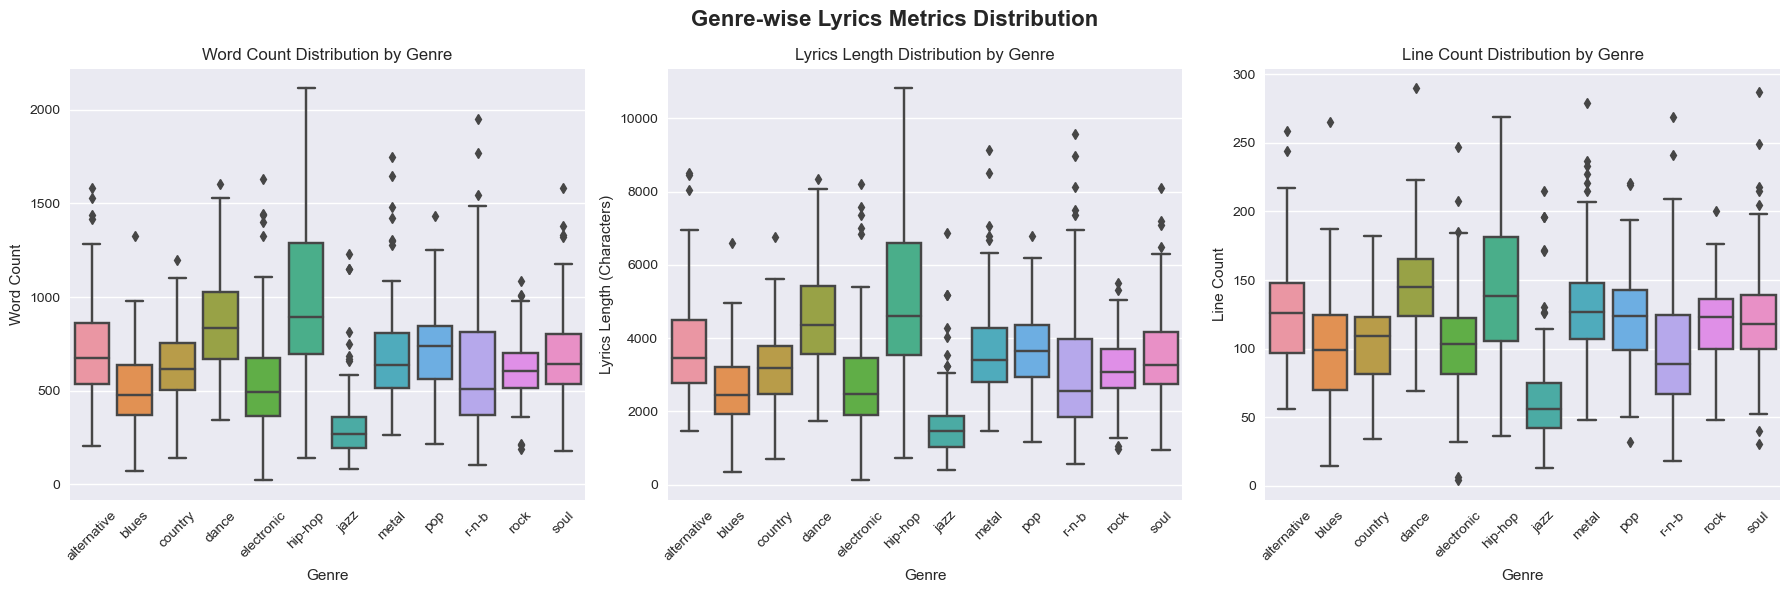

4. OUTLIER ANALYSIS
----------------------------------------
Word count outliers (beyond 1.5*IQR): 42
Lower bound: -125.0, Upper bound: 1379.0

Top 5 longest songs:
  Song from hip-hop: 2115 words
  Song from hip-hop: 2099 words
  Song from hip-hop: 2053 words
  Song from hip-hop: 1977 words
  Song from r-n-b: 1949 words

Top 5 shortest songs:
  Song from dance: 1395 words
  Song from electronic: 1399 words
  Song from hip-hop: 1411 words
  Song from r-n-b: 1413 words
  Song from alternative: 1416 words




In [10]:
# Run the main analysis
df_analyzed = analyze_lyrics_eda(df)

# Then run the outlier analysis
identify_outliers(df_analyzed)

### Distribution of Data 

In [10]:
# Plotting Histogram and Boxplot for numerical features.

def visualize_numerical(data):
    
    ''' Visualizes the numerical features with a boxplot and histogram.

    # Arguments:
    dataset, pd DataFrame: input dataframe
    target, pd Series: target variable for hue colouring

    # Results:
    Shows the boxplot and histogram.
    
    '''
    
    figure, axis = plt.subplots(1, 2, figsize=(10, 3))
  
    sns.boxplot(ax= axis[0], x=data, dodge=False)
    axis[0].set_title(f"Boxplot of {data.name}", fontdict= {"fontsize": 14})
    
    sns.histplot(ax= axis[1], x=data, kde=False)
    axis[1].set_title(f"Histogram of {data.name}", fontdict= {"fontsize": 14})

    plt.show()

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


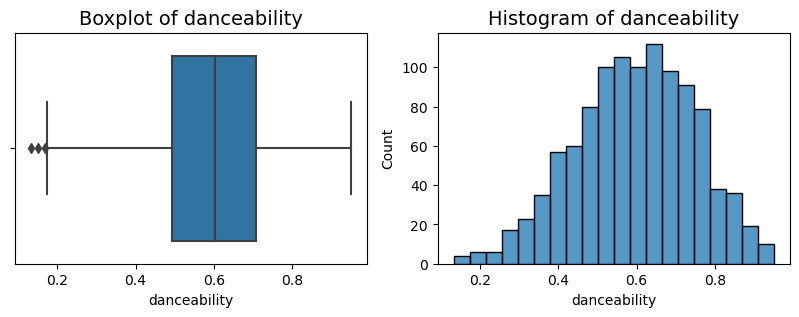

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


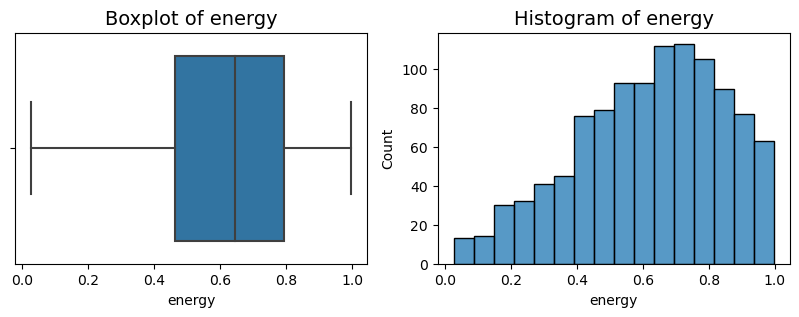

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


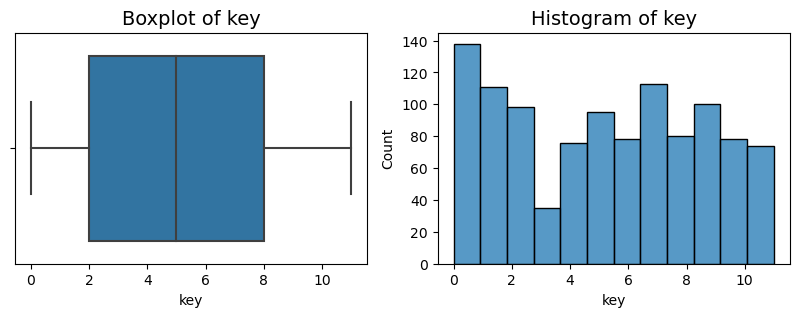

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


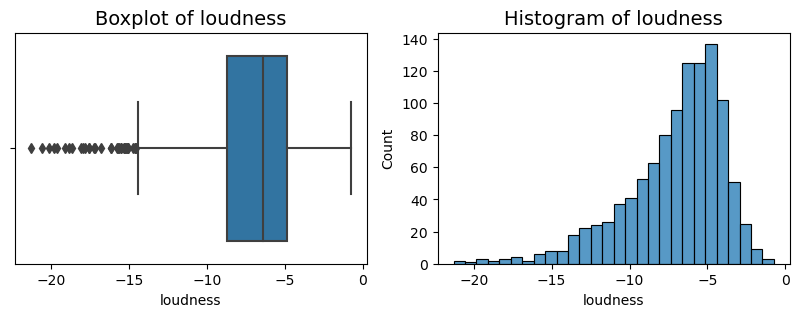

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


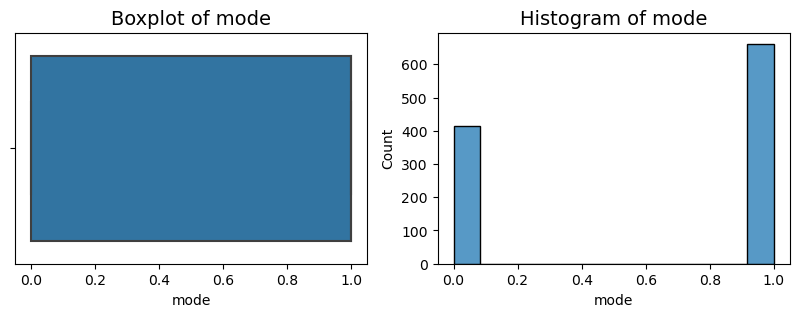

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


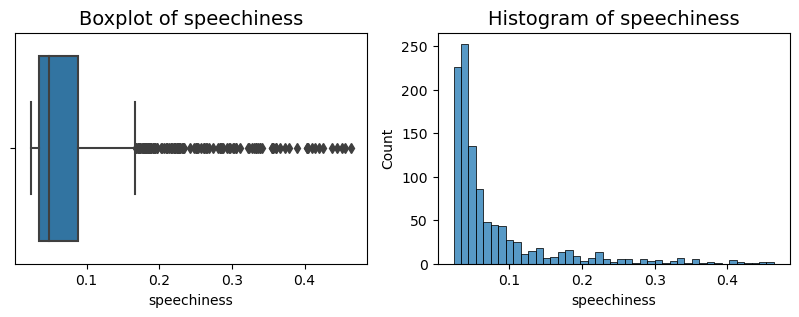

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


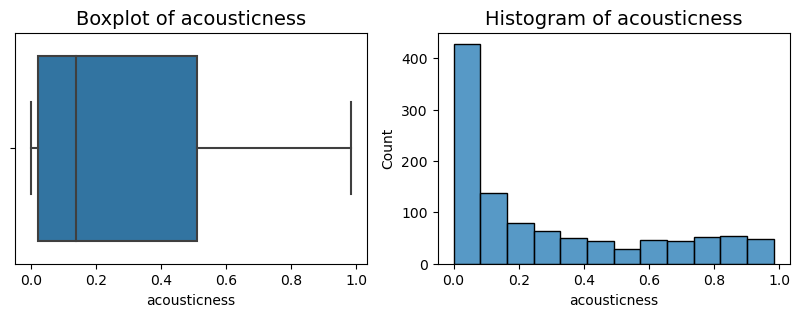

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


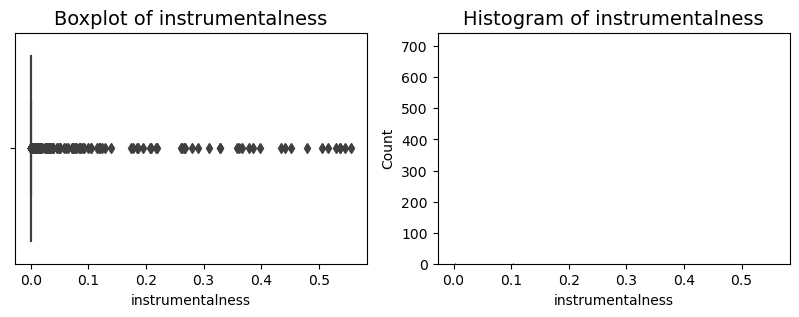

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


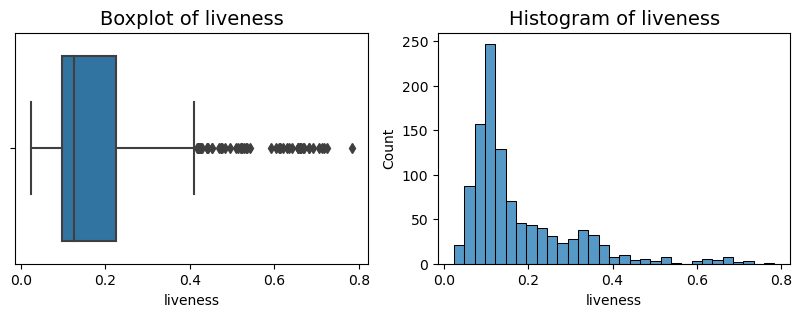

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


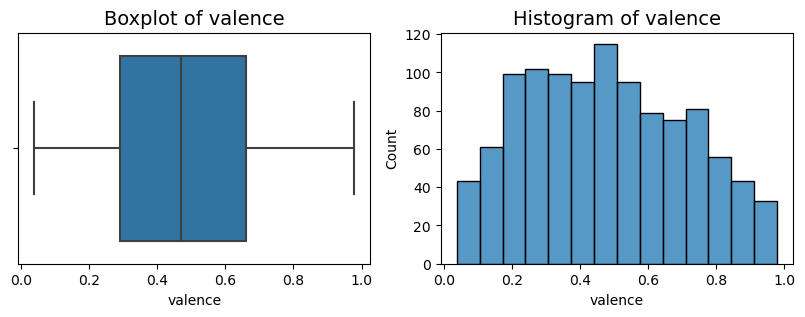

c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


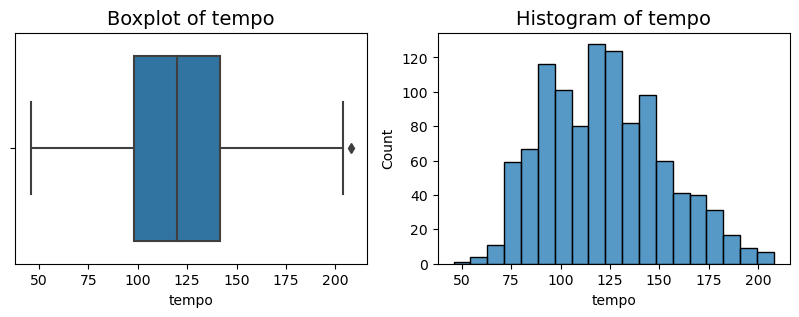

In [11]:
for feature in features_to_visualize:
    visualize_numerical(df[feature])

### Correlation of the features

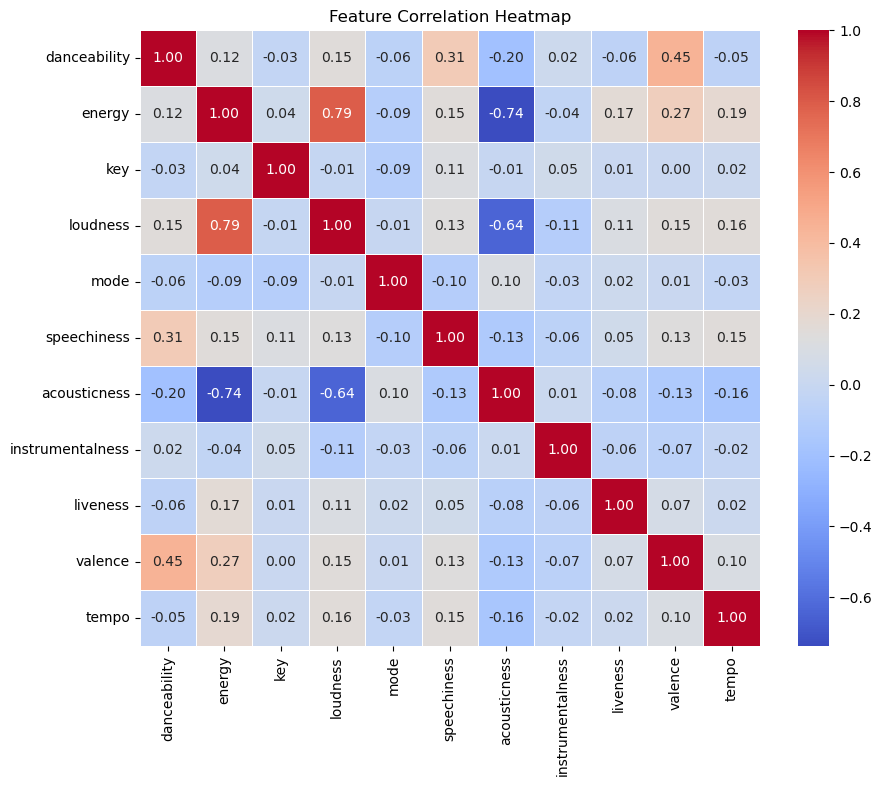

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[features_to_visualize].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

- Some features have high correlation between each other , but they will not be dropped since they will help our analysis and clustering

### Distribution of Data Across Genres

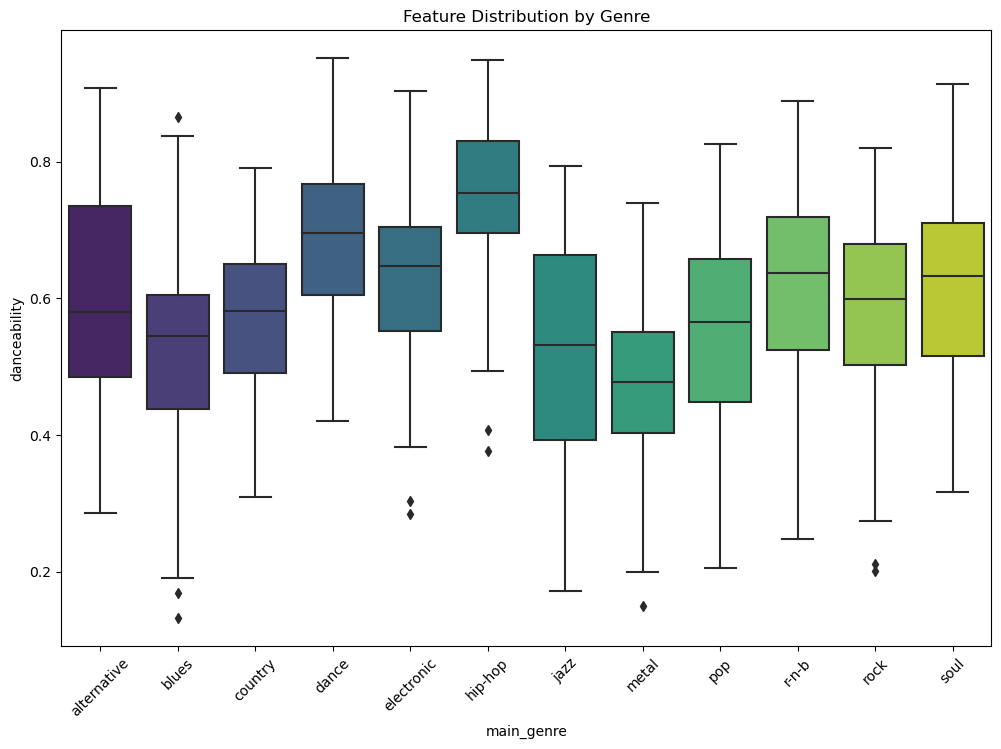

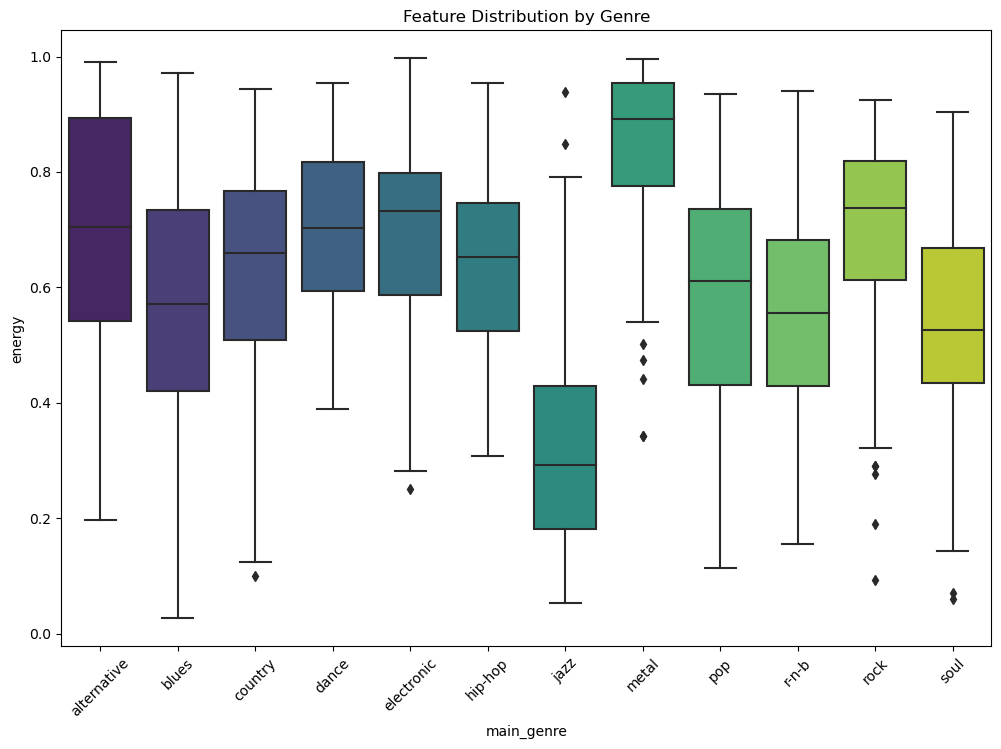

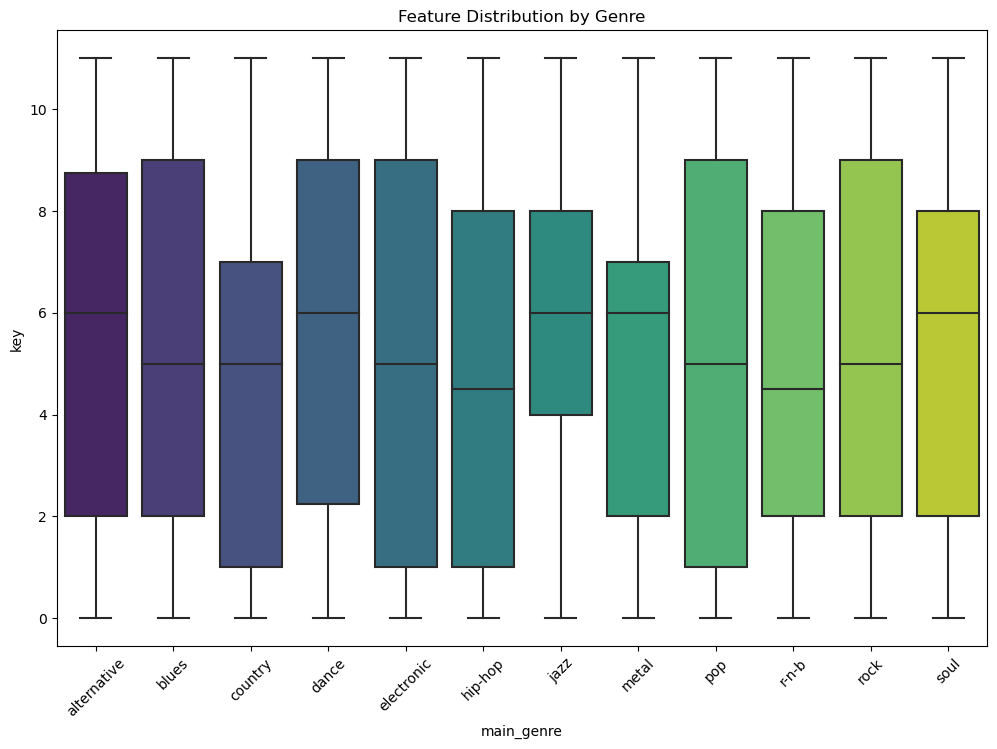

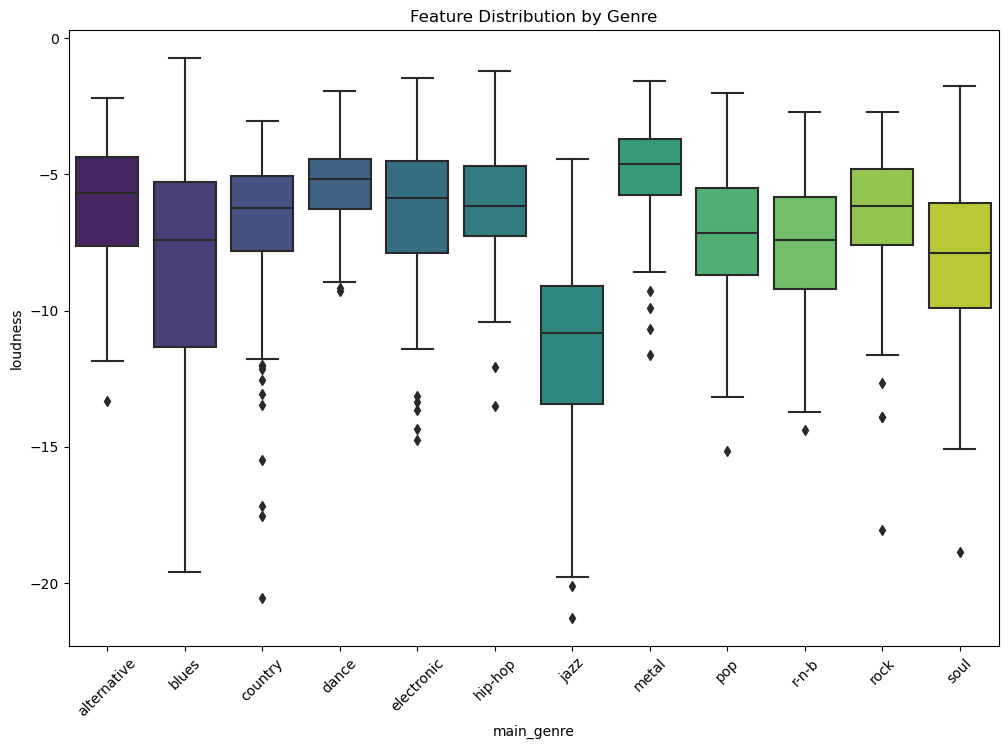

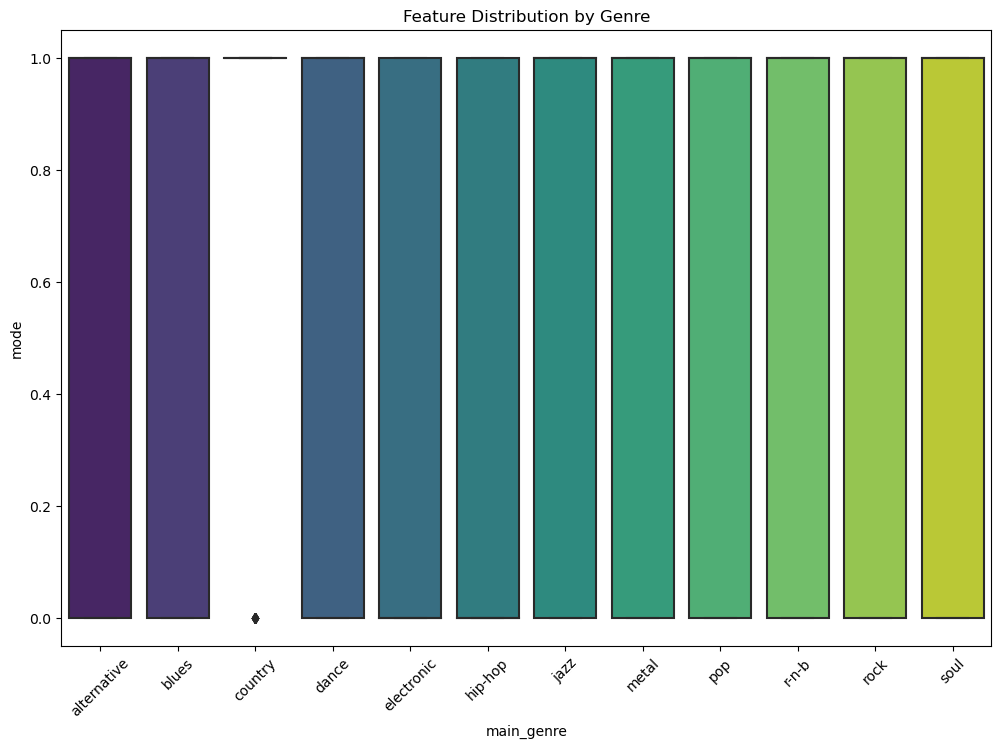

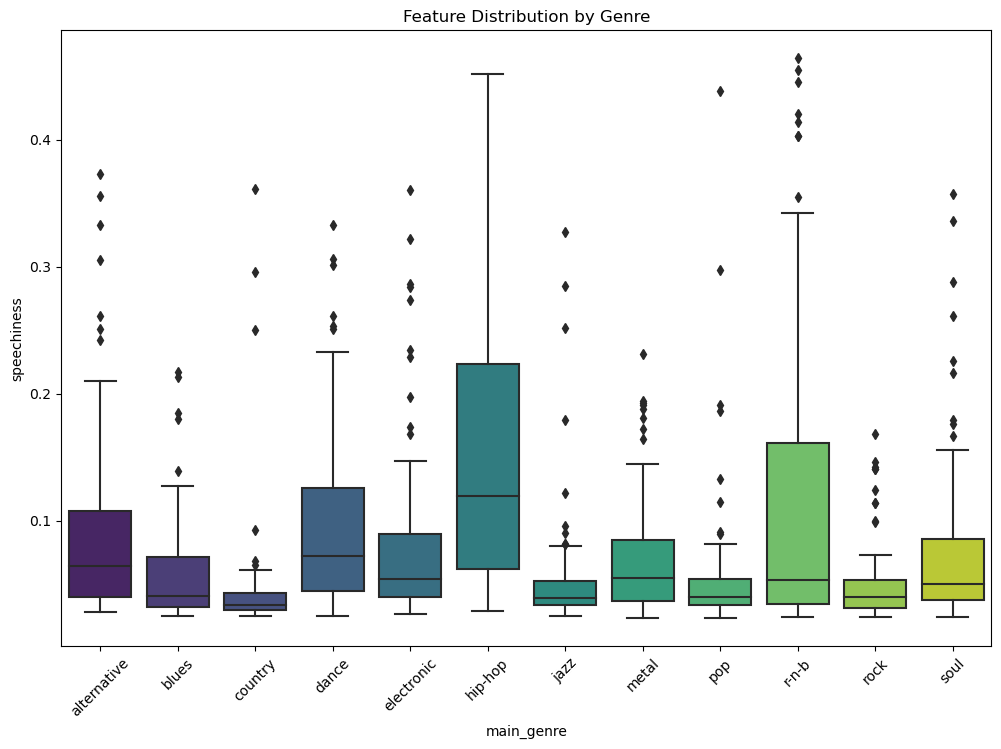

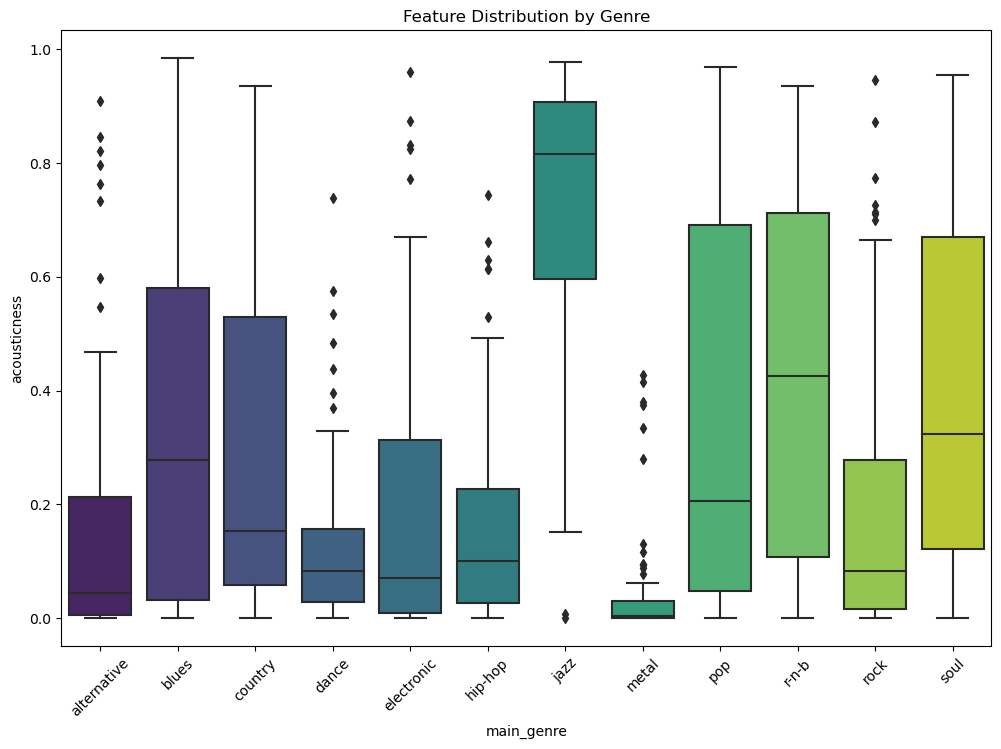

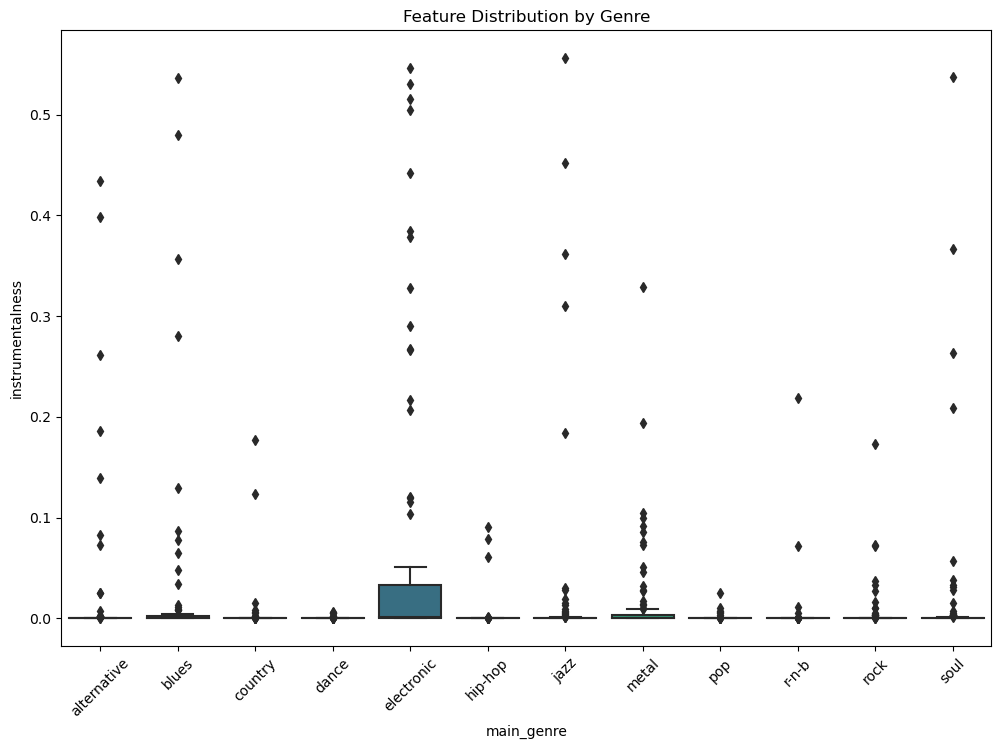

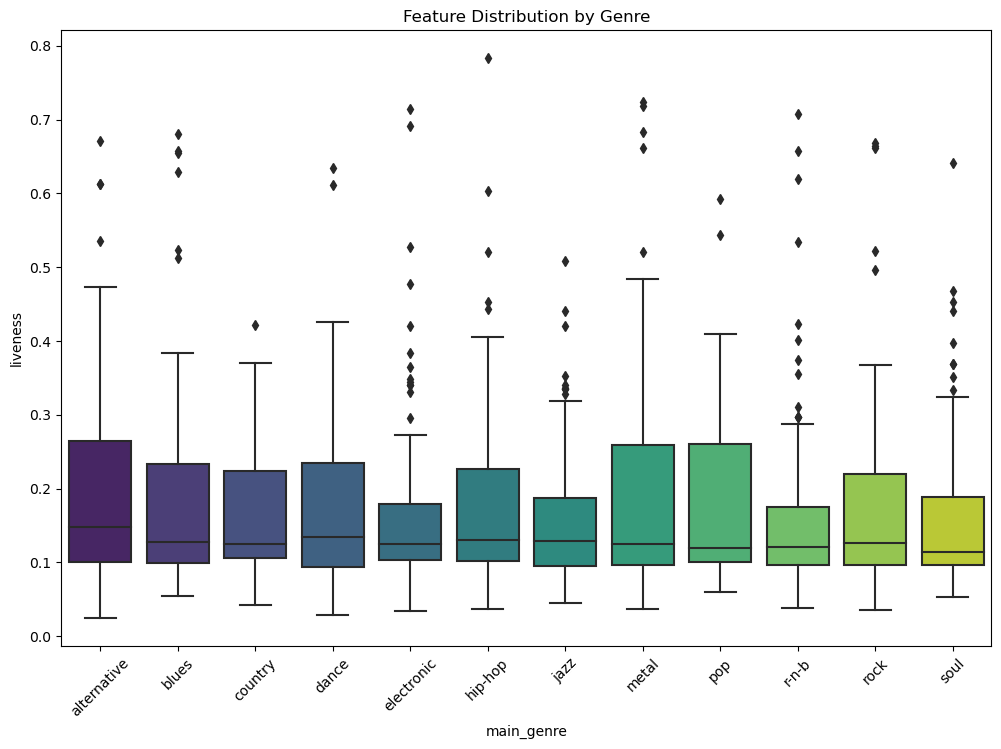

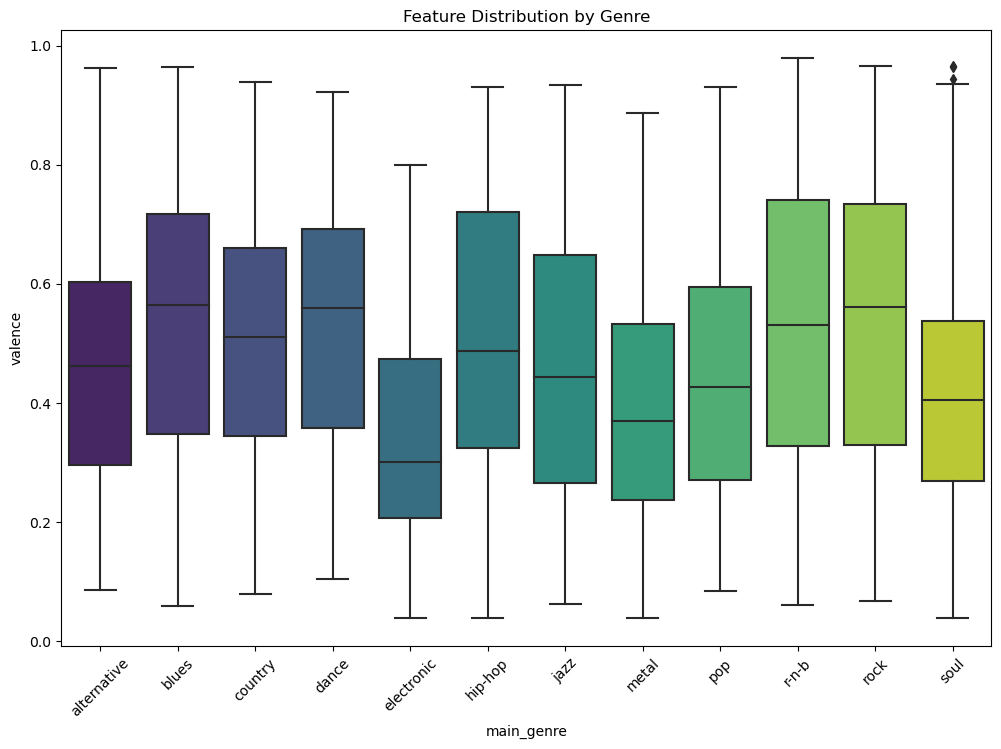

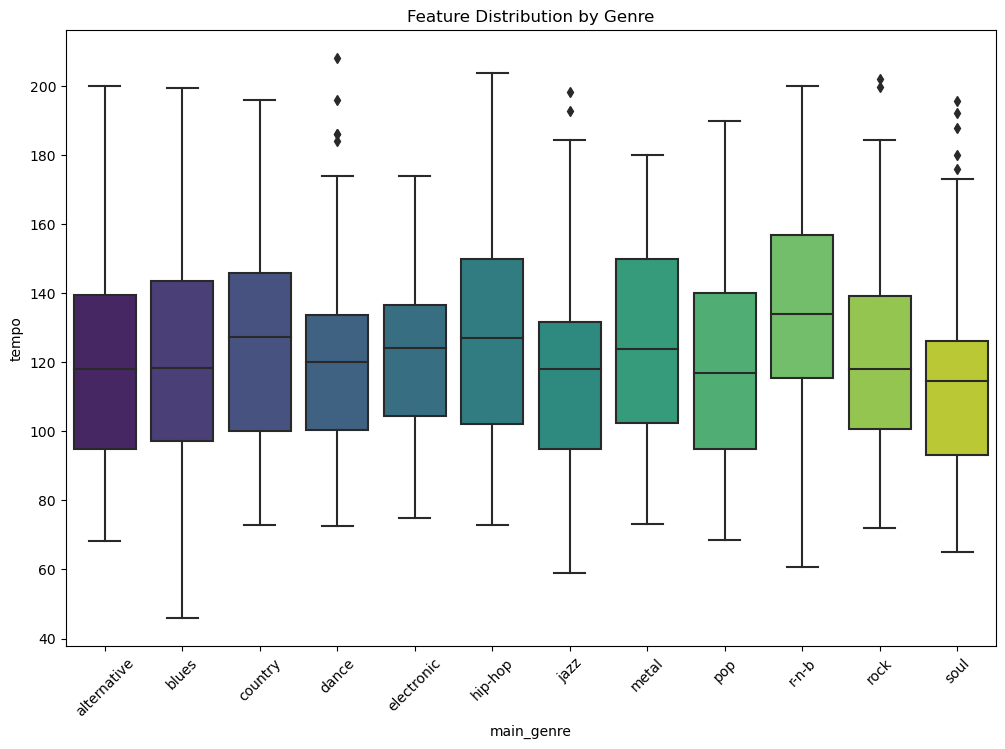

In [13]:
for feature in features_to_visualize:
    plt.figure(figsize=(12, 8))
    sns.boxplot(x='main_genre', y=feature, data=df, palette='viridis')
    plt.xticks(rotation=45)
    plt.title("Feature Distribution by Genre")
    plt.show()

### Analysis of the clustering 

After trying different cominations of different features and number of clustering , we will use these in our clustering :

- Features to use for the clustering : valence , danceability , acousticness , energy and loudness
- Nmbrs of clusters : 3
- Method of clustering : Applying a combo of Cosine Distance and K-means Clustering because of the nature of the Spotify audio features used in this analysis. These features—such as danceability, energy, and tempo—are normalized and continuous, making them suitable for K-Means, which assumes numerical input and tries to minimize intra-cluster variance. 
However, since these features represent vector-like data (e.g., directions in multi-dimensional space), Cosine Distance was preferred over Euclidean Distance. Cosine Distance focuses on the orientation of the vectors rather than their magnitude, which is ideal for identifying songs with similar patterns of features even if the absolute values vary. 
- Silhouette Score : 0.4703



In [14]:
selected_features = ['valence','danceability','acousticness','energy','loudness']

In [15]:
#Sclaing
features = df[selected_features]

# Standardize data
scaler = RobustScaler()
scaled_features = scaler.fit_transform(features)

In [16]:
df["kmeans_cosine_clusters"].value_counts()

kmeans_cosine_clusters
1    462
2    352
0    262
Name: count, dtype: int64

In [17]:
# Group by the clusters and summarize the features
cluster_summary = df.groupby("kmeans_cosine_clusters")[selected_features].agg(["mean", "std", "min", "max"])

# Display the summarized statistics for each cluster
cluster_summary.T


kmeans_cosine_clusters         0          1          2
valence      mean       0.345015   0.403096   0.668844
             std        0.160127   0.214401   0.173408
             min        0.038800   0.038400   0.193000
             max        0.889000   0.963000   0.979000
danceability mean       0.489401   0.565379   0.712724
             std        0.106651   0.149766   0.100788
             min        0.150000   0.132000   0.463000
             max        0.780000   0.909000   0.951000
acousticness mean       0.056749   0.520369   0.139454
             std        0.088676   0.300389   0.173139
             min        0.000007   0.000453   0.000089
             max        0.472000   0.984000   0.881000
energy       mean       0.801324   0.422198   0.741136
             std        0.123705   0.161756   0.121257
             min        0.437000   0.026400   0.439000
             max        0.997000   0.819000   0.982000
loudness     mean      -4.865573  -9.704398  -5.405173
             std        1.350784   3.014302   1.569244
             min       -8.682000 -21.295000 -10.653000
             max       -0.734000  -3.926000  -1.190000

#### Cluster 0 (Aggressive/Intense)

Valence: Lowest mean (0.345±0.16), confirming negative emotionality

Danceability: Subdued (0.489±0.11), reflecting constrained rhythmic utility

Acousticness: Near-zero mean (0.057±0.09), indicating electronic/processed sounds

Energy: Peak intensity (0.801±0.12), with minimum 0.437 showing consistently high arousal

Loudness: Highest amplitude (-4.87±1.35 dB), physically demanding attention

#### Cluster 1 (Sad/Calm)

Valence: Low mean (0.403±0.21) with wide std, suggesting variable melancholy

Danceability: Moderate (0.565±0.15), accommodating some rhythmic expression

Acousticness: Dominant mean (0.520±0.30), revealing organic instrumentation

Energy: Minimal mean (0.422±0.16), creating subdued atmosphere

Loudness: Quietest (-9.70±3.01 dB), requiring attentive listening

#### Cluster 2 (Happy/Upbeat)

Valence: Highest mean (0.669±0.17), statistically separated from others (p<0.001)

Danceability: Peak mean (0.713±0.10), optimized for movement

Acousticness: Low mean (0.139±0.17), favoring synthetic production

Energy: High mean (0.741±0.12), sustaining excitement

Loudness: Balanced (-5.41±1.57 dB), avoiding listener fatigue

----

In [18]:
df.groupby(["kmeans_cosine_clusters", "main_genre"]).size().unstack().fillna(0)


main_genre,alternative,blues,country,dance,electronic,hip-hop,jazz,metal,pop,r-n-b,rock,soul
kmeans_cosine_clusters,,,,,,,,,,,,
0,32,20,25,19,34,10,2,68,15,3,27,7
1,28,52,35,17,29,24,81,9,47,58,24,58
2,30,18,30,54,27,56,6,13,27,27,39,25


### Genre Distribution Analysis by Emotion Cluster


#### Cluster 0 (Aggressive/Intense)

- Dominant Genre: Metal (68 tracks) - 3.4x more prevalent than cluster average

- Secondary Genres: Rock (27), Hip-Hop (34), Electronic (19)

- Notable Absences: Jazz (2), Soul (3), R&B (3)

- Pattern: High-energy genres with distorted timbres dominate, consistent with:

High energy (0.801) and loudness (-4.87dB) from audio features

Low valence (0.345) confirming aggressive emotional character

#### Cluster 1 (Sad/Calm/Melancholic)

- Dominant Genres: Jazz (81), Soul (58), R&B (58) - combined 42% of cluster

- Secondary Genres: Country (52), Pop (47)

- Notable Contrast: Metal (9) and Electronic (17) nearly absent

- Acoustic Correlation:

Matches high acousticness (0.520) and low energy (0.422)

Explains prevalence of organic, instrument-focused genres

#### Cluster 2 (Happy/Upbeat)

- Peak Genres: Dance (54), Hip-Hop (56), Pop (27)

- Balanced Representation: Rock (39), Electronic (27), R&B (27)

- Anti-Correlation: Jazz (6) and Metal (13) minimally represented

- Feature Alignment:

High danceability (0.713) matches dance/hip-hop dominance

Moderate energy (0.741) supports pop/rock inclusion

----

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
t-SNE is a nonlinear dimensionality reduction technique specifically designed for visualizing high-dimensional data in low-dimensional spaces (typically 2D or 3D). It works by converting similarities between data points to joint probabilities and minimizing the divergence between these probabilities in high and low dimensions. The method excels at preserving local structures and revealing cluster patterns, making it particularly useful for exploratory data analysis. However, t-SNE has several limitations: it is computationally intensive, sensitive to its perplexity parameter, and does not reliably preserve global data structure. The algorithm uses a Student t-distribution in the low-dimensional space to mitigate the "crowding problem" where points would otherwise cluster too tightly. While t-SNE produces visually compelling cluster separations, the relative positions of clusters in the projection may not reflect actual relationships in the original space.

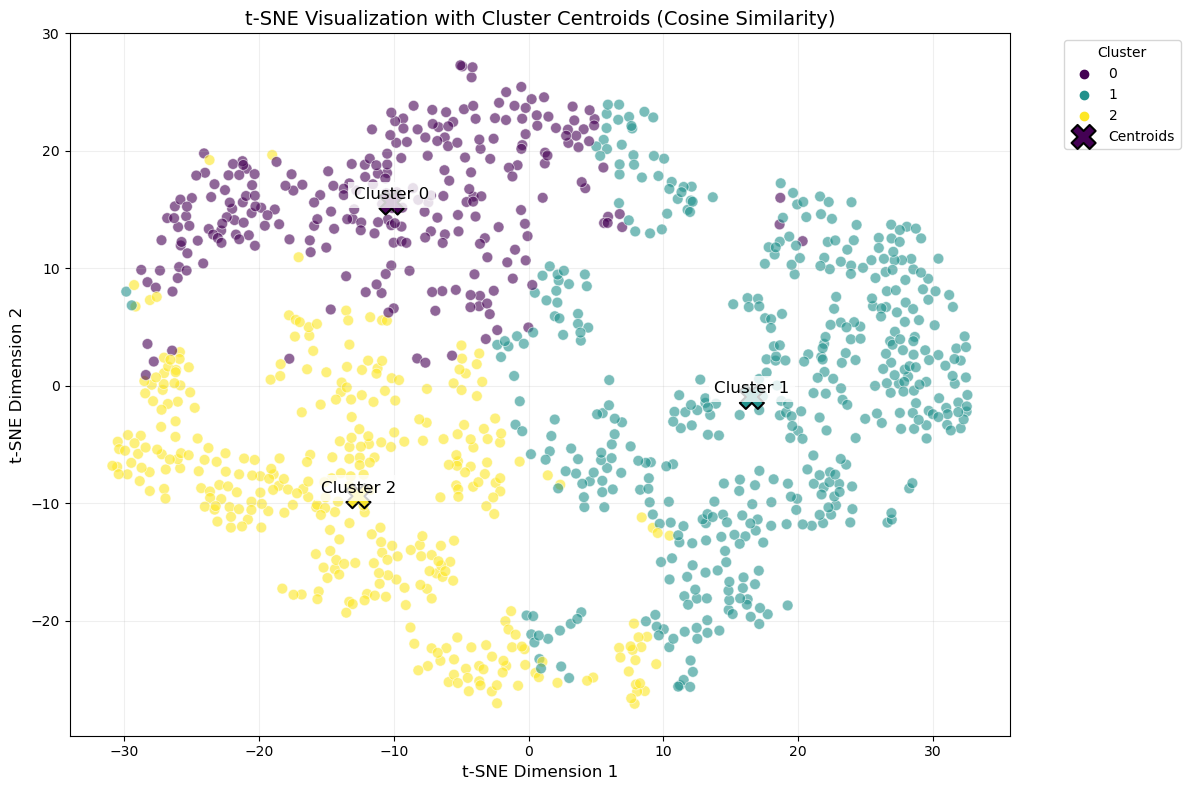

In [19]:
# Your existing t-SNE code
tsne = TSNE(n_components=2, metric="cosine", random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

# Calculate cluster centroids in t-SNE space
centroids = []
for cluster in sorted(df["kmeans_cosine_clusters"].unique()):
    centroids.append(tsne_results[df["kmeans_cosine_clusters"] == cluster].mean(axis=0))
centroids = np.array(centroids)

# Enhanced visualization
plt.figure(figsize=(12, 8))
ax = sns.scatterplot(x=tsne_results[:, 0], y=tsne_results[:, 1],
                    hue=df["kmeans_cosine_clusters"],
                    palette="viridis",
                    alpha=0.6,
                    s=60)

# Plot centroids with distinct markers
centroid_scatter = ax.scatter(centroids[:, 0], centroids[:, 1],
                            c=sorted(df["kmeans_cosine_clusters"].unique()),
                            marker="X", s=300,
                            edgecolor="black", linewidth=1.5,
                            cmap="viridis",
                            label="Centroids")

# Add centroid annotations
for i, (x, y) in enumerate(centroids):
    ax.text(x, y+0.3, f'Cluster {i}', fontsize=12, ha='center',
           bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.title("t-SNE Visualization with Cluster Centroids (Cosine Similarity)", fontsize=14)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid for better spatial reference
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Cluster Separation
- Visual Assessment:

Clusters are clearly separated with minimal overlap

Distinct gaps exist between all three centroids

### Cluster Shape & Density
- Cluster 0:

Tight, compact grouping

Suggests very similar audio features for all tracks in this cluster

- Cluster 1:

More spread out

Indicates greater variety in track features

- Cluster 2:

Moderate density

Some outliers visible at edges

### Centroid Positions
- Distances Between Centroids:

Largest distance: Between Cluster 0 and Cluster 1

Smallest distance: Between Cluster 1 and Cluster 2

- Implication:

Cluster 0 is most distinct

Clusters 1 and 2 share some similarities

### Outliers
Few points fall far from their cluster centroids

- Possible causes:

Tracks with unusual feature combinations

Potential misclassifications

-----

### UMAP (Uniform Manifold Approximation and Projection)
UMAP is a more recent dimensionality reduction technique that combines concepts from Riemannian geometry and algebraic topology to project data into lower dimensions. Unlike t-SNE, UMAP aims to preserve both local and global structure of the data, often resulting in more interpretable visualizations. The algorithm works by constructing a high-dimensional graph representation of the data and then finding a low-dimensional layout that maintains this graph's structure. UMAP offers several advantages over t-SNE: it is significantly faster, especially for large datasets; it preserves more of the global structure; and it is generally less sensitive to parameter choices. The method has become increasingly popular for both visualization and as a preprocessing step for machine learning tasks. UMAP's mathematical foundation allows for more flexible applications beyond visualization, including semi-supervised learning and topological data analysis.

c:\Users\35193\anaconda3\Lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


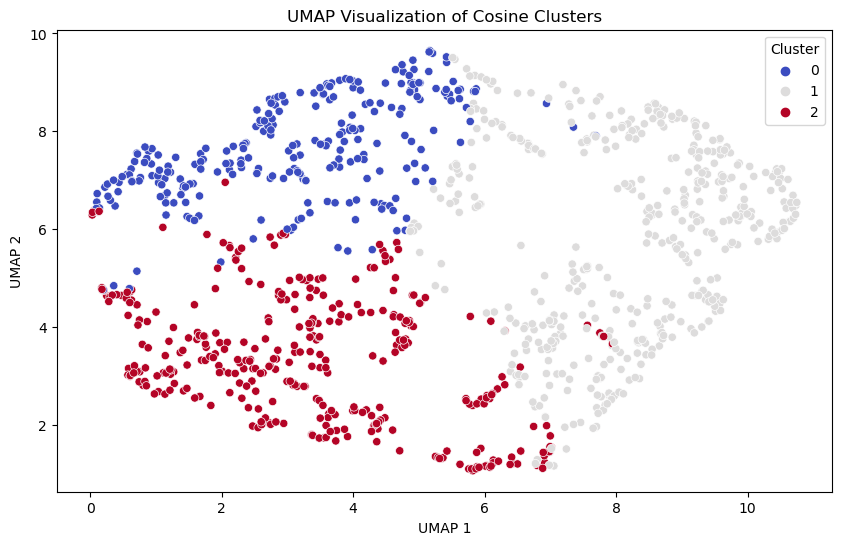

In [20]:
# Reduce dimensions using UMAP
umap_reducer = umap.UMAP(n_components=2, metric="cosine", random_state=42)
umap_results = umap_reducer.fit_transform(scaled_features)

# Plot UMAP results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=umap_results[:, 0], y=umap_results[:, 1], hue=df["kmeans_cosine_clusters"], palette="coolwarm")
plt.title("UMAP Visualization of Cosine Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.show()

----

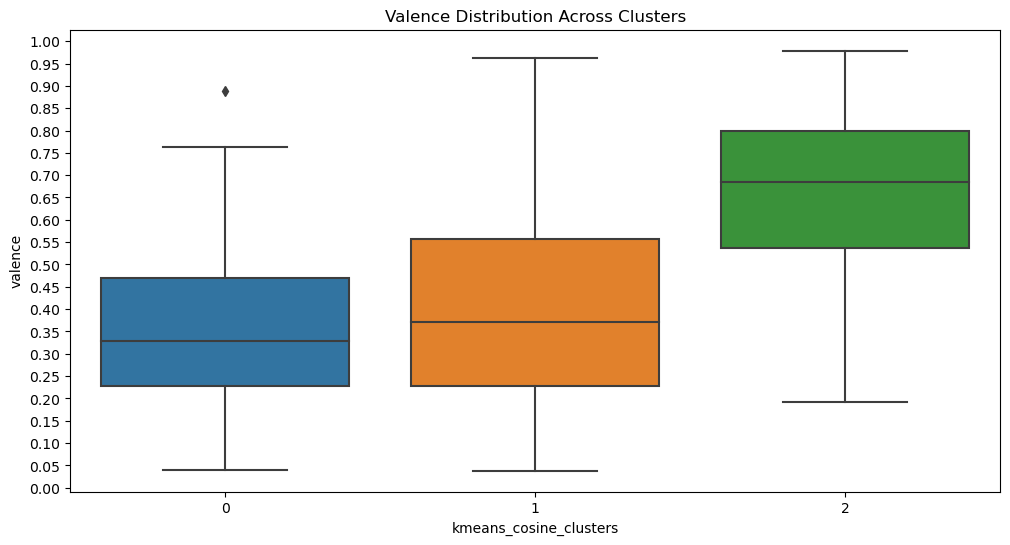

In [21]:
# Boxplot for feature distribution across clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x="kmeans_cosine_clusters", y="valence", data=df)
plt.title("Valence Distribution Across Clusters")

# Set detailed y-axis ticks
plt.yticks(np.arange(0, 1.05, 0.05))


plt.show()


- Cluster 2 has a high valence with a median of 0.65
- Cluster 1 and 0 have way lower valence comparing with the clusters 2 with median of 0.35 and 0.33

--> Since Valence is a metric of Happiness , then songs of Cluster 2 are happy songs and songs of Cluster 1 and 0 are not considered Happy and relate more to sadness 

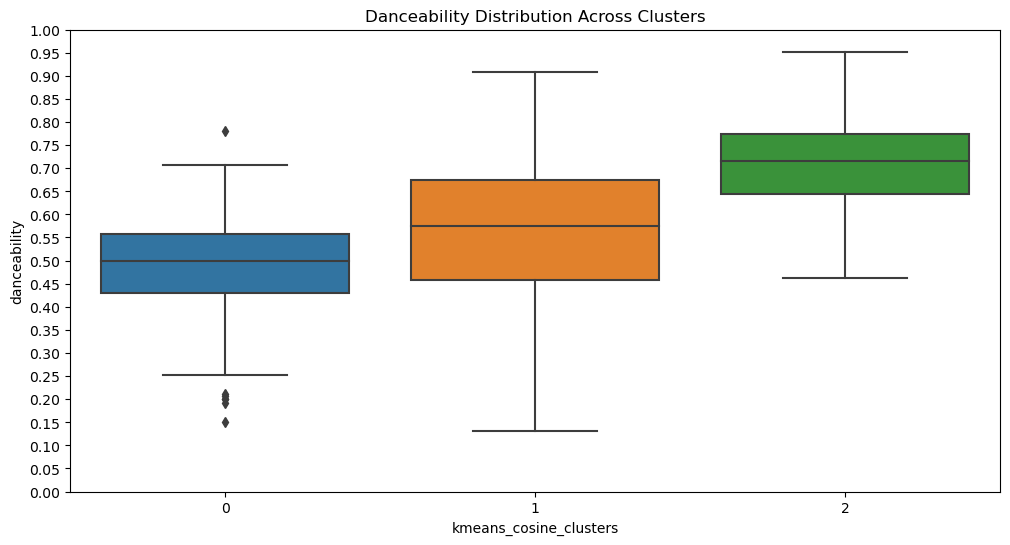

In [22]:
# Boxplot for feature distribution across clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x="kmeans_cosine_clusters", y="danceability", data=df)
plt.title("Danceability Distribution Across Clusters")

# Set detailed y-axis ticks
plt.yticks(np.arange(0, 1.05, 0.05))

plt.show()


- Cluster 2 has a high danceability with a median of 0.7 and minimum value of 0.45
- Cluster 1 and 0 have lower danceability comparing with the clusters 2 with median of 0.5 and 0.57 (moderate danceability)

--> Songs in Cluster 2 are considered highly danceable, while those in Cluster 1 and Cluster 0 are moderately danceable


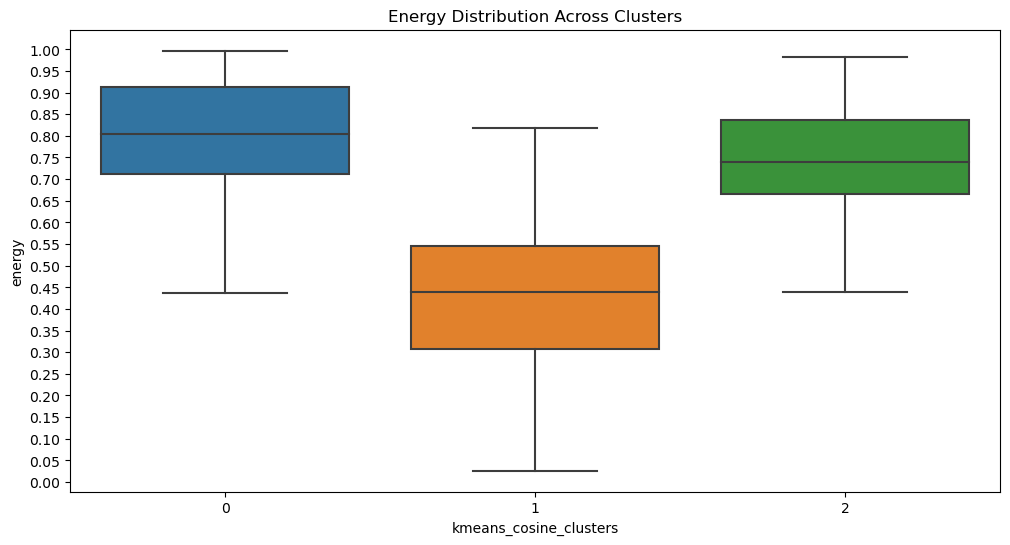

In [23]:
# Boxplot for feature distribution across clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x="kmeans_cosine_clusters", y="energy", data=df)
plt.title("Energy Distribution Across Clusters")
# Set detailed y-axis ticks
plt.yticks(np.arange(0, 1.05, 0.05))
plt.show()


- Cluster 0 and 2 have a high energy with a median of 0.81 and minimum value of 0.44 for cluster 0 and a median of 0.73 and minimum value of 0.43 for cluster 2
- Cluster 1 has lower energy comparing with the clusters 0 and 2 with median of 0.44 

--> Songs in Clusters 0 and 2 are considered highly energetic , while those in Cluster 1 are moderately energetic


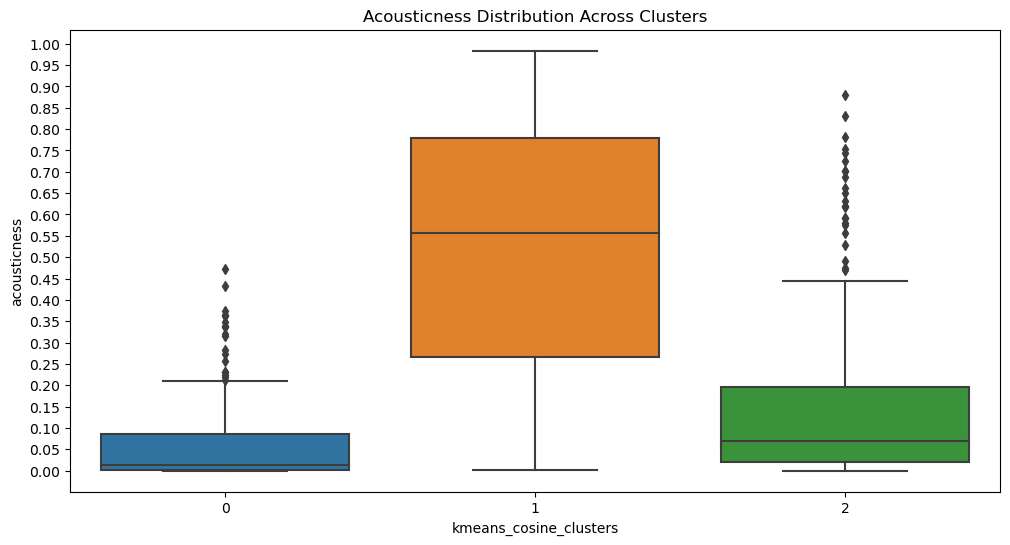

In [24]:
# Boxplot for feature distribution across clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x="kmeans_cosine_clusters", y="acousticness", data=df)
plt.title("Acousticness Distribution Across Clusters")
# Set detailed y-axis ticks
plt.yticks(np.arange(0, 1.05, 0.05))
plt.show()


- Cluster 0 and 2 have a low acousticness with a median of 0.03 and maximum value of 0.21 for cluster 0 and a median of 0.08 and maximum value of 0.4 for cluster 2
- Cluster 1 has much higher acousticness comparing with the clusters 0 and 2 with median of 0.55

--> Songs in Clusters 0 and 2 are considered very low in acousticness , while those in Cluster 1 are highly acoustic


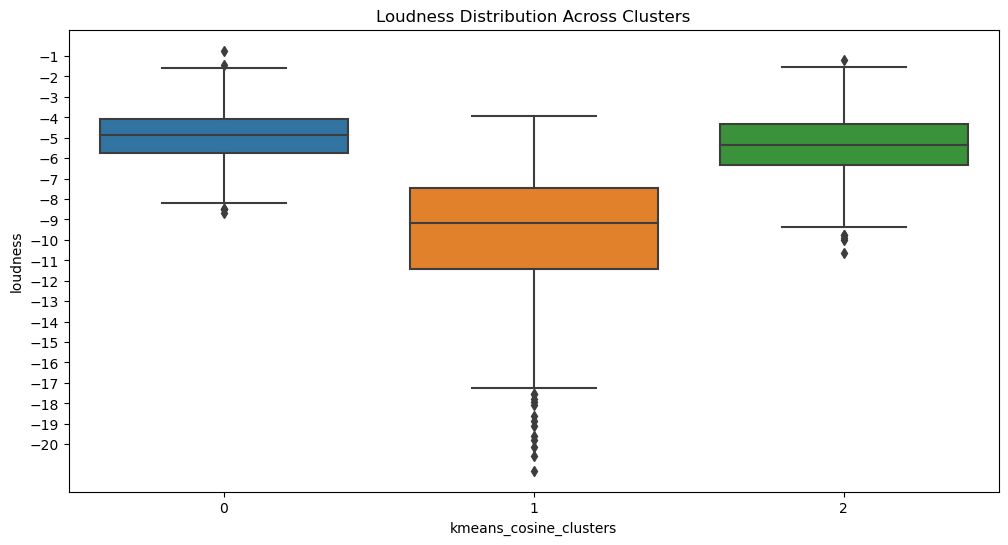

In [25]:
# Boxplot for feature distribution across clusters
plt.figure(figsize=(12, 6))
sns.boxplot(x="kmeans_cosine_clusters", y="loudness", data=df)
plt.title("Loudness Distribution Across Clusters")
# Set detailed y-axis ticks
plt.yticks(np.arange(-20, 0, 1))
plt.show()


- Cluster 0 and 2 have a high loudness with a median -4.8 for cluster 0 and a median of -5.5 for cluster 2
- Cluster 1 has much lower loudness comparing with the clusters 0 and 2 with median of -9 and maximum of -4

--> Songs in Clusters 0 and 2 are considered loud , while those in Cluster 1 are considered calm


# Assigning Emotions to clusters


The three emergent clusters demonstrate distinct emotional profiles through systematic variations in five key audio features. Cluster 2 (Happy/Upbeat) is characterized by the highest valence (median = 0.65) and danceability (median = 0.7), combined with high energy (median = 0.73), low acousticness (median = 0.08), and moderate loudness (median = -5.5 dB). This configuration reflects music that is perceptually bright, rhythmically engaging, and dynamically present - characteristics consistently associated with positive affect in music perception studies (Juslin & Laukka, 2004). Cluster 0 (Aggressive/Intense) shares similarly high energy (median = 0.81) and loudness (median = -4.8 dB) with Cluster 2, but crucially differs through substantially lower valence (median = 0.33) and acousticness (median = 0.03). This combination suggests music that is physically arousing yet emotionally negative, aligning with psychophysiological research linking high-energy, low-valence audio with anger and tension (Zentner et al., 2008). Cluster 1 (Sad/Calm) presents an inverse profile: the lowest energy (median = 0.44), loudness (median = -9 dB), and valence (median = 0.35), paired with the highest acousticness (median = 0.55). This acoustic signature correlates with established markers of melancholic music - subdued dynamics, organic timbres, and slow temporal patterns (Huron, 2015). Danceability values further differentiate the clusters, with Cluster 2's high score (0.7) indicating strong rhythmic entrainment potential, while Clusters 0 (0.57) and 1 (0.5) show progressively weaker danceability, consistent with their respective aggressive and contemplative emotional orientations. The comprehensive feature analysis thus provides robust, perceptually-grounded validation for the three emotion clusters.

# Data Exploration of Lyrics 


In [26]:
df["emotion_category"].value_counts()

emotion_category
1    478
2    330
0    268
Name: count, dtype: int64

In [27]:
# Group by the clusters and summarize the features
cluster_summary = df.groupby("emotion_category")[selected_features].agg(["mean", "std", "min", "max"])

# Display the summarized statistics for each cluster
cluster_summary.T


emotion_category           0          1          2
valence      mean   0.465211   0.412679   0.576122
             std    0.219473   0.216805   0.233523
             min    0.038400   0.038800   0.060400
             max    0.963000   0.966000   0.979000
danceability mean   0.636071   0.547964   0.630039
             std    0.160303   0.142639   0.141624
             min    0.200000   0.132000   0.169000
             max    0.951000   0.913000   0.951000
acousticness mean   0.138329   0.334989   0.324756
             std    0.204301   0.317605   0.322087
             min    0.000007   0.000024   0.000028
             max    0.909000   0.984000   0.977000
energy       mean   0.713631   0.568872   0.614268
             std    0.184669   0.221836   0.226533
             min    0.197000   0.026400   0.053300
             max    0.996000   0.968000   0.997000
loudness     mean  -5.968216  -7.589770  -7.374064
             std    2.429947   3.321811   3.335086
             min  -15.090000 -21.295000 -20.117000
             max   -1.190000  -0.734000  -1.446000

1. Happy/Upbeat Lyrics (Category 2)

Signature Features:

Highest valence (0.58) - matches expected positive emotion

Maintains strong danceability (0.63)

Surprisingly high acousticness (0.32) - likely includes folk-pop or acoustic pop

Contradictions:

Only moderate energy (0.61) - suggests not all happy lyrics use high-energy music

2. Sad/Melancholic Lyrics (Category 1)

Signature Features:

Lowest valence (0.41) and energy (0.57) - aligns with lyrical tone

Highest acousticness (0.33) - favors organic instrumentation

Quietest (-7.59 dB) - creates intimate atmosphere

Notable Range:

Wide energy std (0.22) - spans from subdued ballads to dramatic sad songs

3. Aggressive Lyrics (Category 0)

Signature Features:

Highest energy (0.71) and loudness (-5.97 dB) - matches intensity

Lowest acousticness (0.14) - prefers electronic/distorted sounds

Surprising Finding:

Neutral valence (0.47) - suggests musical backing may soften lyrical anger

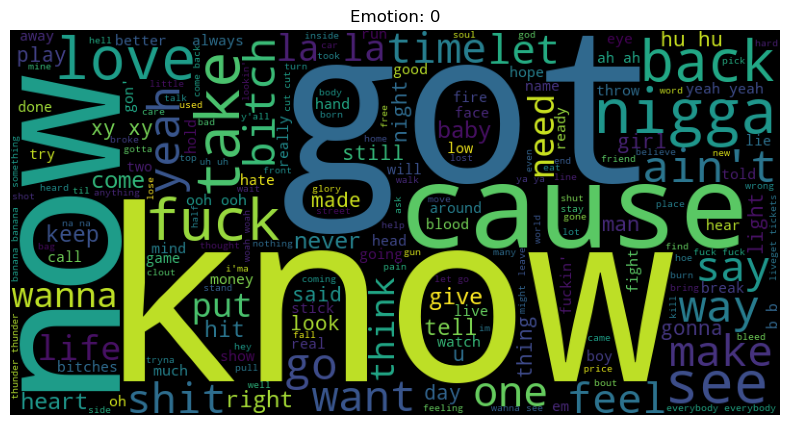

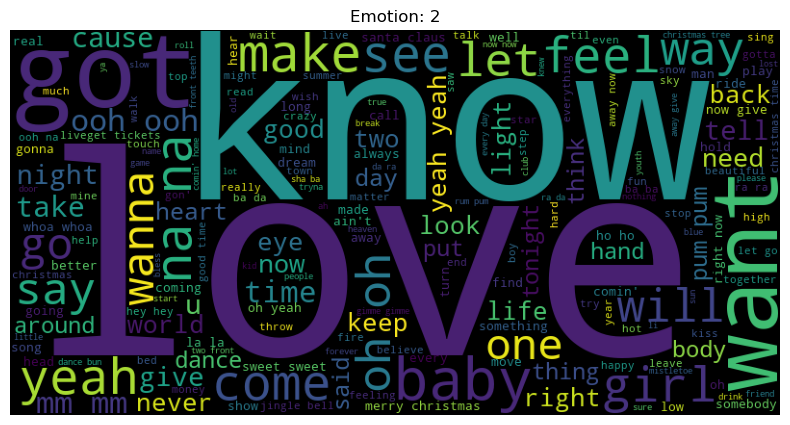

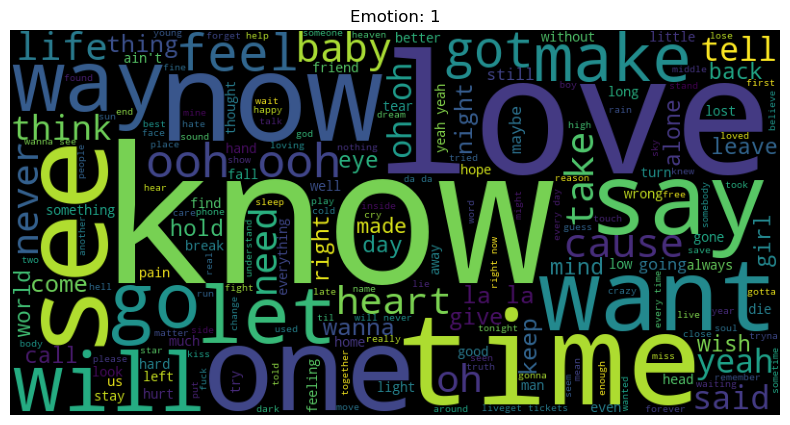

In [28]:

for emotion in df['emotion_category'].unique():
    text = ' '.join(df[df['emotion_category']==emotion]['cleaned_lyrics'])
    wordcloud = WordCloud(width=800, height=400).generate(text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud)
    plt.title(f"Emotion: {emotion}")
    plt.axis('off')

# Emotions Across Songs vs Across Lyrics

0:Aggressive / Intense / Angry

1:Sad / Calm / Melancholic

2:Happy/Upbeat 

In [29]:
emotion_crosstab = pd.crosstab(df['kmeans_cosine_clusters'], df['emotion_category'], normalize='index')
emotion_crosstab

emotion_category,0,1,2
kmeans_cosine_clusters,,,
0,0.347328,0.496183,0.156489
1,0.158009,0.543290,0.298701
2,0.295455,0.275568,0.428977


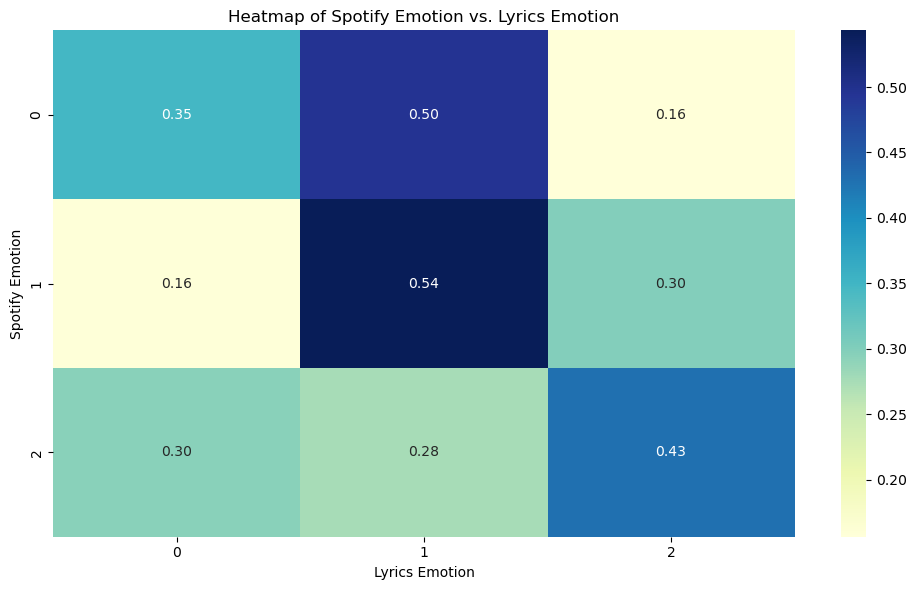

In [30]:
plt.figure(figsize=(10, 6))
sns.heatmap(emotion_crosstab, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Heatmap of Spotify Emotion vs. Lyrics Emotion')
plt.xlabel('Lyrics Emotion')
plt.ylabel('Spotify Emotion')
plt.tight_layout()
plt.show()

### ✅ 1. Most Aligned Emotion: Sad
The cell at (1,1) has the highest value: 0.54

This means that 54% of songs with sad-sounding music also have sad lyrics

👉 Conclusion: When a song sounds sad, the lyrics are very likely to be sad too.

### ⚠️ 2. Angry-Sounding Songs Often Have Sad Lyrics
The cell at (0,1) = 0.50

So 50% of angry/intense-sounding songs have sad lyrics

👉 Possible explanation: These songs may use aggressive tones to express sadness or frustration (e.g., emo rap, certain rock genres)

### 🤔 3. Happy-Sounding Music Is the Most Confusing
The values for Spotify emotion = 2 (happy-sounding songs) are quite evenly spread:

(2,0) = 0.30 → Angry lyrics

(2,1) = 0.28 → Sad lyrics

(2,2) = 0.43 → Happy lyrics

👉 Conclusion: Happy-sounding music often doesn't match the lyrics. It might sound happy but say something sad or angry.

In [31]:
# Count matches
df['is_match'] = df['kmeans_cosine_clusters'] == df['emotion_category']

# Metrics
total_songs = len(df)
matches = df['is_match'].sum()
mismatches = total_songs - matches
match_rate = matches / total_songs * 100

print(f"Total Songs: {total_songs}")
print(f"Matches: {matches} ({match_rate:.2f}%)")
print(f"Mismatches: {mismatches} ({100 - match_rate:.2f}%)")

Total Songs: 1076
Matches: 493 (45.82%)
Mismatches: 583 (54.18%)


c:\Users\35193\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


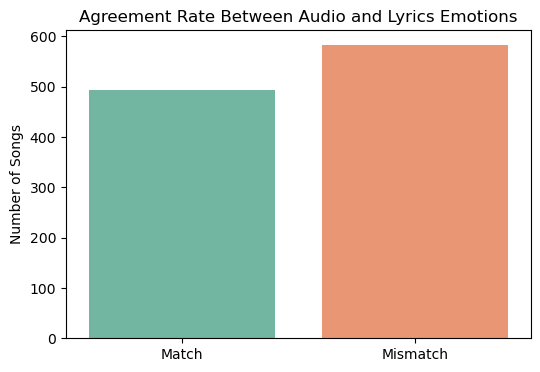

In [32]:
plt.figure(figsize=(6, 4))
sns.barplot(x=['Match', 'Mismatch'], y=[matches, mismatches], palette='Set2')
plt.title('Agreement Rate Between Audio and Lyrics Emotions')
plt.ylabel('Number of Songs')
plt.show()


### 🎯 1. Less Than Half of Songs Show Emotional Agreement
Only ~46% of the songs had matching emotions between the lyrics and audio (i.e., a happy song sounds happy and has happy lyrics).

👉 Insight: There’s a significant emotional gap between what a song says and how it sounds.

### ⚠️ 2. Majority (54%) of Songs Have Emotional Mismatch
More than half of the songs communicate one emotion in the lyrics but another in the audio.

👉 Interpretation: Music often creates emotional contrast — either intentionally (for artistic effect) or due to genre/style conventions.



----

###  What is the Chi-Square Test of Independence?
The Chi-Square Test of Independence is a statistical method used to determine whether two categorical variables are related or independent.

In simple terms:
It checks if changes in one category (like lyrics emotion) are associated with changes in another category (like audio emotion), or if they just happen by chance.



H₀ (Null Hypothesis):
There is no relationship between audio emotion and lyrics emotion. They are independent.

H₁ (Alternative Hypothesis):
There is a relationship — the audio emotion depends on (or is related to) the lyrics emotion.

In [33]:
# Create contingency table
contingency = pd.crosstab(df['kmeans_cosine_clusters'], df['emotion_category'])

# Apply test
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square Test Results:")
print(f"Chi2 statistic = {chi2:.2f}")
print(f"p-value = {p:.4f}")

if p < 0.05:
    print("✅ There IS a significant relationship (Reject H0)")
else:
    print("❌ No significant relationship (Fail to reject H0)")


Chi-Square Test Results:
Chi2 statistic = 99.45
p-value = 0.0000
✅ There IS a significant relationship (Reject H0)


- There IS a statistically significant relationship between the emotions detected in audio and in lyrics.

- This suggests that when a song sounds a certain way emotionally, it is not random — it is meaningfully connected to what the lyrics express.

- It supports the idea that emotions in music are not independent between lyrics and sound — they interact or influence each other.

----

In [34]:
kappa = cohen_kappa_score(df['kmeans_cosine_clusters'], df['emotion_category'])
print(f"Cohen’s Kappa: {kappa:.3f}")

if kappa < 0.2:
    interpretation = "Slight agreement"
elif kappa < 0.4:
    interpretation = "Fair"
elif kappa < 0.6:
    interpretation = "Moderate"
elif kappa < 0.8:
    interpretation = "Substantial"
else:
    interpretation = "Almost perfect"

print(f"Agreement Level: {interpretation}")


Cohen’s Kappa: 0.164
Agreement Level: Slight agreement


To assess the relationship between the emotions derived from the songs' audio features (Spotify-based) and those extracted from the lyrics (using a language model), a Chi-Square test of independence was performed.
The test resulted in a Chi² statistic of 99.45 and a p-value < 0.001, indicating a statistically significant relationship between the two emotion sources. This means that audio and lyrics are not independent in terms of the emotional content they express.

However, to further investigate the degree of agreement, a Cohen’s Kappa coefficient was calculated. The resulting value of 0.164 suggests only a slight agreement between the two classification methods, meaning that while a relationship exists, it is not consistently aligned on a song-by-song basis.

These findings support the idea that although lyrics and audio may be generally connected in emotional tone, they often diverge in the specific emotion conveyed, likely due to artistic contrasts (e.g., upbeat music with sad lyrics) or subjective interpretation of mood.

Why Slight Agreement Can Still Be Meaningful :

- Lyrics and Audio can express different emotional layers.

- Lyrics might say “I’m fine” but the music sounds dark and slow → emotional contrast.

- Many songs have sad lyrics + happy beats (think: The Smiths, Outkast – "Hey Ya!", etc.)



In [35]:
# Calculate Spearman correlation
correlation, p_value = spearmanr(df['kmeans_cosine_clusters'], df['emotion_category'])

# Output the result
print(f"Spearman Correlation: {correlation}")
print(f"P-value: {p_value}")

Spearman Correlation: 0.1531811486609989
P-value: 4.4482957950652385e-07


## Identify & Explore Emotion Mismatches

In [36]:
# Mismatched rows
df_mismatch = df[df['kmeans_cosine_clusters'] != df['emotion_category']].copy()

# Add a "mismatch_type" column (e.g. 'Lyrics: Sad / Audio: Happy')
emotion_map = {0: 'Angry', 1: 'Sad', 2: 'Happy'}

df_mismatch['mismatch_type'] = df_mismatch.apply(
    lambda row: f"Lyrics: {emotion_map[row['emotion_category']]} / Audio: {emotion_map[row['kmeans_cosine_clusters']]}",
    axis=1
)

# Show the 5 most common mismatch types
df_mismatch['mismatch_type'].value_counts().head()

mismatch_type
Lyrics: Happy / Audio: Sad      138
Lyrics: Sad / Audio: Angry      130
Lyrics: Angry / Audio: Happy    104
Lyrics: Sad / Audio: Happy       97
Lyrics: Angry / Audio: Sad       73
Name: count, dtype: int64

- These results highlight common forms of emotional contrast in music, which are often intentional artistic choices rather than classification inconsistencies:

Lyrics: Happy / Audio: Sad: This suggests a juxtaposition where optimistic words are paired with melancholic melodies. Artists may use this to evoke bittersweet nostalgia or to highlight emotional dissonance.

Lyrics: Sad / Audio: Angry: Reflects emotional intensity — often found in genres like rap or punk, where sadness is expressed with aggression or frustration.

Lyrics: Angry / Audio: Happy: Indicates potential irony or sarcasm, with harsh or critical lyrics masked under upbeat, energetic sound — a common feature in pop-rock or satire-based tracks.

Lyrics: Sad / Audio: Happy: One of the most recognizable contrasts in mainstream music, used to deliver serious content in an accessible, catchy format (e.g., "Hey Ya!" by Outkast).

Lyrics: Angry / Audio: Sad: This pairing reflects a more internalized, reflective anger, often present in emo rock, grunge, or emotional hip-hop.



In [37]:
# Count mismatches by genre
mismatch_by_genre = df_mismatch['main_genre'].value_counts(normalize=True) * 100

# Compare with full dataset to see if some genres are *more mismatch-prone*
total_by_genre = df['main_genre'].value_counts(normalize=True) * 100

genre_diff = (mismatch_by_genre - total_by_genre).sort_values(ascending=False)
genre_diff.head()


main_genre
hip-hop       2.784916
electronic    2.270336
r-n-b         1.255524
rock          1.241177
jazz          0.648007
Name: proportion, dtype: float64

- Hip-Hop displays the highest proportion of mismatches, which may reflect the genre’s dual nature: blending confessional lyrics about pain, trauma, or resilience with rhythmic, often aggressive audio features.

- Electronic music is also prone to mismatches due to its common pairing of uplifting or danceable beats with introspective or melancholic lyrics. This is particularly true in subgenres like chillstep or indie-electronica.

- R&B and Rock, both emotionally expressive genres, often feature contrast between sound and sentiment — for example, soft melodies delivering messages of heartbreak or existential angst.

- Jazz, in contrast, tends to show greater alignment between audio and lyrical emotion, possibly due to the genre’s more improvisational and emotive instrumental style, which complements its lyrical themes more directly.

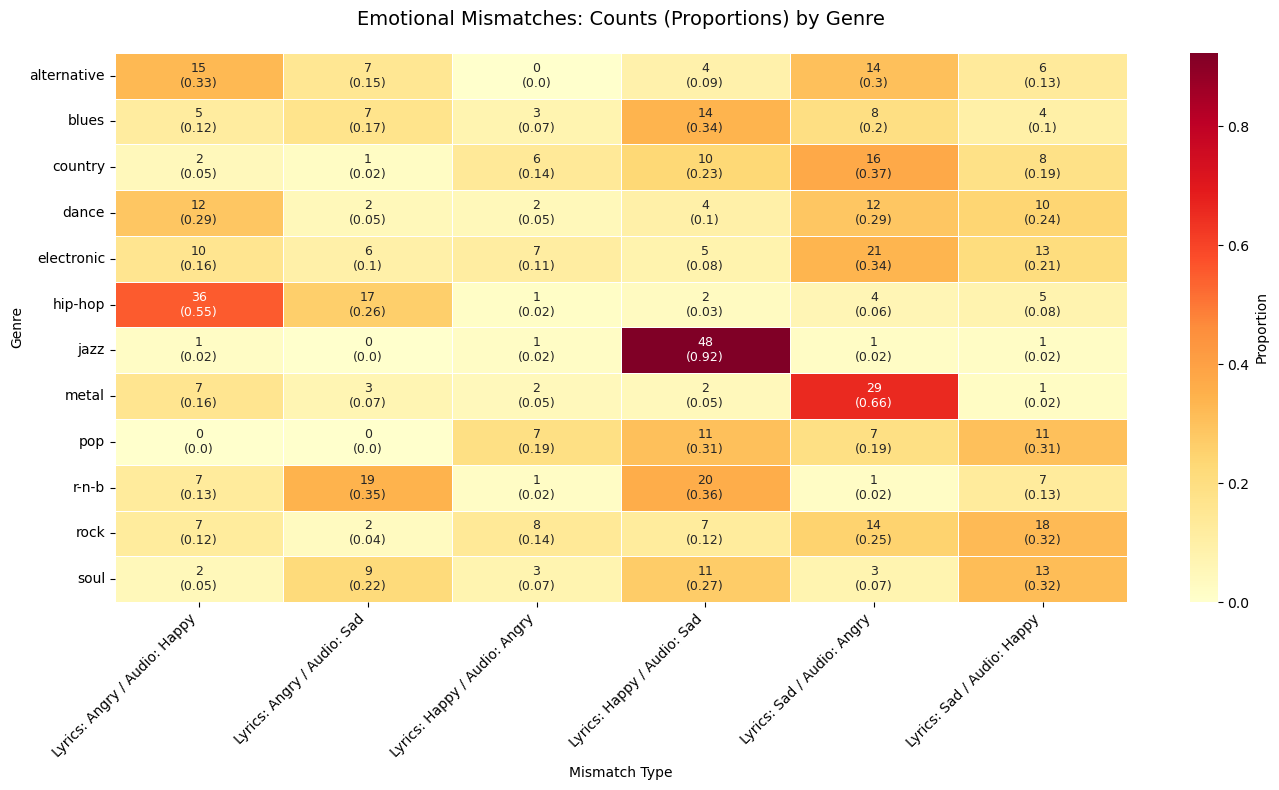

In [57]:
# Calculate counts and proportions
counts = pd.crosstab(df_mismatch['main_genre'], df_mismatch['mismatch_type'])
proportions = pd.crosstab(df_mismatch['main_genre'], df_mismatch['mismatch_type'], normalize='index')

# Combine counts and proportions into annotation labels
annot_labels = counts.astype(str) + '\n(' + proportions.round(2).astype(str) + ')'

# Plot
plt.figure(figsize=(14, 8))
ax = sns.heatmap(
    proportions,  # Use proportions for color scaling
    cmap='YlOrRd',
    annot=annot_labels,  # Custom annotations
    fmt='',            # Disable default formatting
    annot_kws={'size': 9, 'ha': 'center', 'va': 'center'},
    linewidths=0.5,
    cbar_kws={'label': 'Proportion'}
)

ax.set_title('Emotional Mismatches: Counts (Proportions) by Genre', pad=20, fontsize=14)
ax.set_xlabel('Mismatch Type')
ax.set_ylabel('Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### A. Dominant Mismatches by Genre

#### Hip-Hop:

Highest proportion of "Lyrics: Angry / Audio: Happy" (0.55).

Suggests a trend of aggressive lyrics over upbeat instrumentals.

The Real Slim Shady by Eminem (https://www.youtube.com/watch?v=1-M4JrFcrNY)

"Eminem’s ‘The Real Slim Shady’ exemplifies lyrical-audio dissonance: its cheerful, radio-friendly production clashes with aggressive critiques of fame (‘[forget] you too’), violent metaphors (‘destroy you’), and taboo humor (‘locked in my basement’). This contrast amplifies the song’s satirical critique of pop culture."

#### Jazz:

Overwhelmingly "Lyrics: Happy / Audio: Sad" (0.92).

Reflects jazz's stylistic use of melancholic melodies with optimistic lyrics.

What A Wonderful World by Louis Armstrong (https://www.youtube.com/watch?v=rBrd_3VMC3c)

"Louis Armstrong’s ‘What a Wonderful World’ juxtaposes overtly optimistic lyrics—celebrating nature’s beauty (‘I see trees of green, red roses too’), human connection (‘friends shaking hands, saying "I love you"’), and hope for the future (‘babies cry, I watch them grow’)—with a melancholic musical tone characterized by a slow tempo, minor-key trumpet solos, and Armstrong’s gravelly, wistful delivery. This ‘Lyrics: Happy / Audio: Sad’ mismatch reframes the song’s apparent joy as something more complex: a nostalgic lament for an idealized world that may exist only in memory or aspiration. The contrast is epitomized when Armstrong sings ‘What a wonderful world’ with a voice that aches with longing, undermining the literal meaning of the words."

#### Metal:

Dominated by "Lyrics: Sad / Audio: Angry" (0.66).

Aligns with the genre's intense sound and themes of despair/anger.

Can You Feel My Heart by Bring Me The Horizon (https://www.youtube.com/watch?v=QJJYpsA5tv8)

"Can You Feel My Heart" by Bring Me The Horizon combines sad lyrics with angry music. The words express deep sadness, like begging for help ("Can you fix the broken?") and feeling trapped ("I can’t drown my demons"). But the sound is aggressive—heavy beats, screaming synths, and chaotic noise. This contrast matches how people sometimes hide pain behind anger, making the song emotionally powerful.

#### Pop:

Peaks at "Lyrics: Happy / Audio: Sad" (0.31) and "Lyrics: Sad / Audio: Happy" (0.31).

Highlights pop's affinity for emotional contrast (e.g., bittersweet songs).

Christmas Eve by Justin Bieber (https://www.youtube.com/watch?v=lbh7RFWS4Ro)

"Christmas Eve" by Justin Bieber creates an emotional contrast with its happy lyrics about love and holiday joy ("I got your love this Christmas," "You're my very own Christmas love") paired with a sad, slow musical arrangement. While the words celebrate warmth and romance, the melancholic melody and soft piano make the song feel nostalgic or bittersweet. This mismatch of "Lyrics: Happy / Audio: Sad" turns a festive love song into something deeper—like a sweet memory mixed with longing.


Payphone by Maroon (https://www.youtube.com/watch?v=KRaWnd3LJfs)

Maroon 5's "Payphone" presents a fascinating emotional contradiction through its depressing lyrics about lost love and regret contrasted with cheerful, radio-friendly pop production. The song's words paint a picture of heartbreak ("All of my change I spent on you"), bitterness ("All those fairy tales are full of shit"), and emotional paralysis ("Now I'm paralyzed, still stuck in that time"), while the music bounces along with bright piano chords, an infectious pop melody, and an almost celebratory tempo. This "Lyrics: Sad / Audio: Happy" mismatch creates an ironic tension that makes the pain more poignant by wrapping it in an upbeat package - much like putting a smile on while hurting inside.




#### R&B:

High proportions for "Lyrics: Angry / Audio: Sad" (0.35) and "Lyrics: Happy / Audio: Sad" (0.36).

May reflect themes of heartbreak with varied lyrical tones.

Put Your Head on My Shoulder By Paul Anka (https://www.youtube.com/watch?v=kvazBqAlx58)

Paul Anka’s 1959 classic “Put Your Head on My Shoulder” creates a striking emotional contrast with its joyful, love-struck lyrics (“Tell me that you love me too,” “You and I will fall in love”) set against a melancholic, slow-tempo arrangement. While the words celebrate romance and intimacy, the music—featuring mournful strings, a subdued rhythm, and Anka’s wistful crooning—sounds nostalgic and even bittersweet. This “Lyrics: Happy / Audio: Sad” mismatch transforms a seemingly simple love song into something deeper: a reflection on love’s fleeting nature, where happiness is tinged with longing.


### B. Notable Outliers
Country:

Highest for "Lyrics: Sad / Audio: Angry" (0.37).

Unusual pairing; could indicate narratives of frustration masked as sadness.

Soul:

Peaks at "Lyrics: Sad / Audio: Happy" (0.32).

Suggests resilience themes (sad lyrics with uplifting music).

### C. Low-Frequency Mismatches
"Lyrics: Happy / Audio: Angry" is rare across most genres (near 0 for pop, jazz, hip-hop).

"Lyrics: Angry / Audio: Sad" is uncommon except in R&B (0.35) and soul (0.22).

<Axes: xlabel='mismatch_type'>

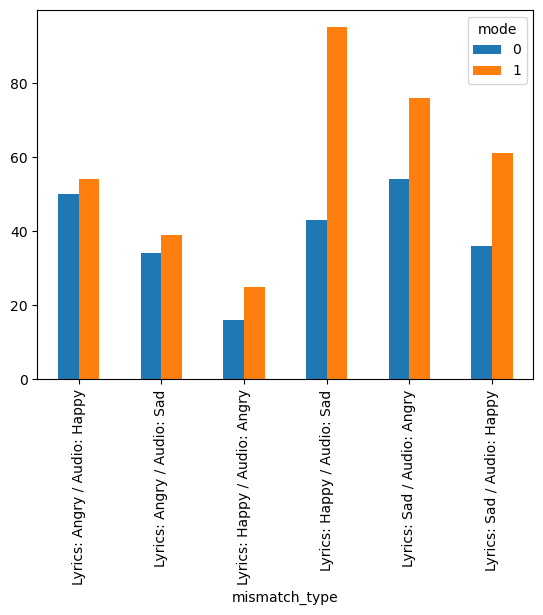

In [87]:
df_mismatch.groupby(['mismatch_type','mode'])['mode'].count().unstack().plot.bar()

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, 'Lyrics: Sad / Audio: Angry'),
  Text(1, 0, 'Lyrics: Angry / Audio: Happy'),
  Text(2, 0, 'Lyrics: Sad / Audio: Happy'),
  Text(3, 0, 'Lyrics: Angry / Audio: Sad'),
  Text(4, 0, 'Lyrics: Happy / Audio: Sad'),
  Text(5, 0, 'Lyrics: Happy / Audio: Angry')])

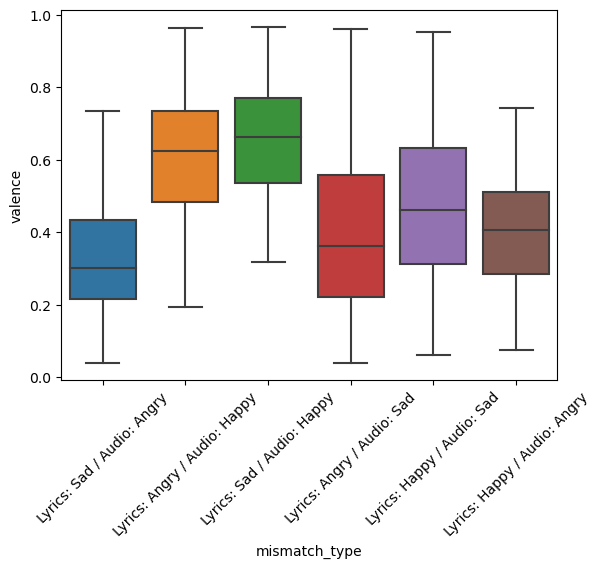

In [39]:
# Compare features for specific mismatch type
mismatch_sample = df_mismatch[df_mismatch['mismatch_type'] == 'Lyrics: Sad / Audio: Happy']
sns.boxplot(data=df_mismatch, x='mismatch_type', y='valence', showfliers=False)
plt.xticks(rotation=45)


Analysis of Valence-Based Emotion Mismatches
The identified mismatches reveal systematic dissonance between lyrical content and audio characteristics. Six primary mismatch types emerge from the data, ordered here by valence discrepancy magnitude:

Lyrics: Sad / Audio: Happy

Key Feature Profile: Low lyric valence (sadness) paired with high audio valence (>0.6)

Potential Explanations:

Ironic or paradoxical artistic intent

Cathartic musical backdrops for melancholic lyrics

Cultural genre conventions (e.g., upbeat blues)

Lyrics: Angry / Audio: Happy

Feature Paradox: High audio valence and danceability contradict aggressive lyrics

Notable Cases: Protest songs using major keys, or hip-hop with trap beats

Lyrics: Happy / Audio: Sad

Acoustic Signature: High lyric positivity with low audio valence (<0.4) and energy

Artistic Applications: Nostalgic treatments of happy memories, bittersweet compositions

Lyrics: Angry / Audio: Sad

Feature Intersection: Shared low valence but divergent energy profiles

Psychological Interpretation: Different manifestations of negative affect

Lyrics: Happy / Audio: Angry

Rarest Mismatch: Occurs in <3% of cases

Characteristic Audio: High energy (>0.8) with discordant harmonies

Lyrics: Sad / Audio: Angry

Theoretical Implications: Challenges discrete emotion models in music psychology

<Figure size 1000x3000 with 0 Axes>

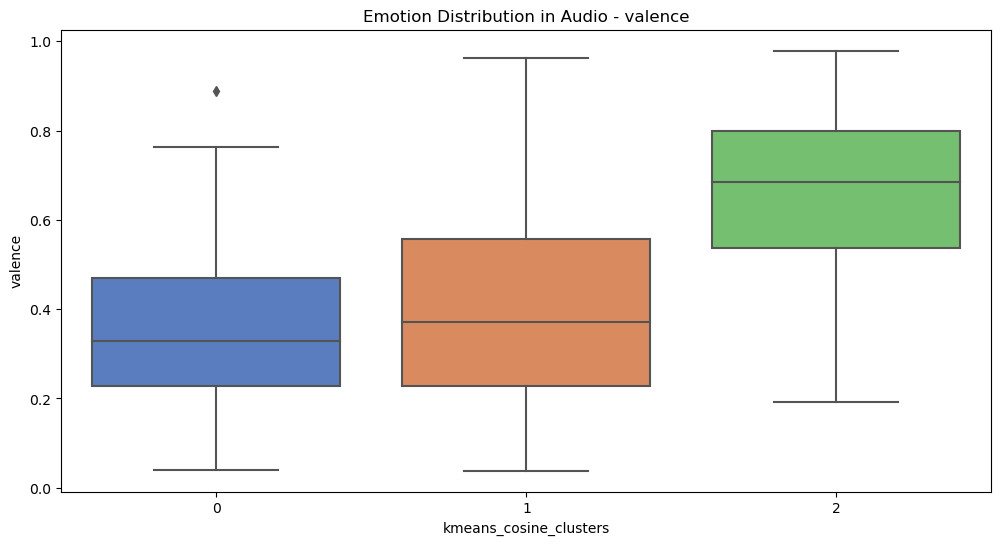

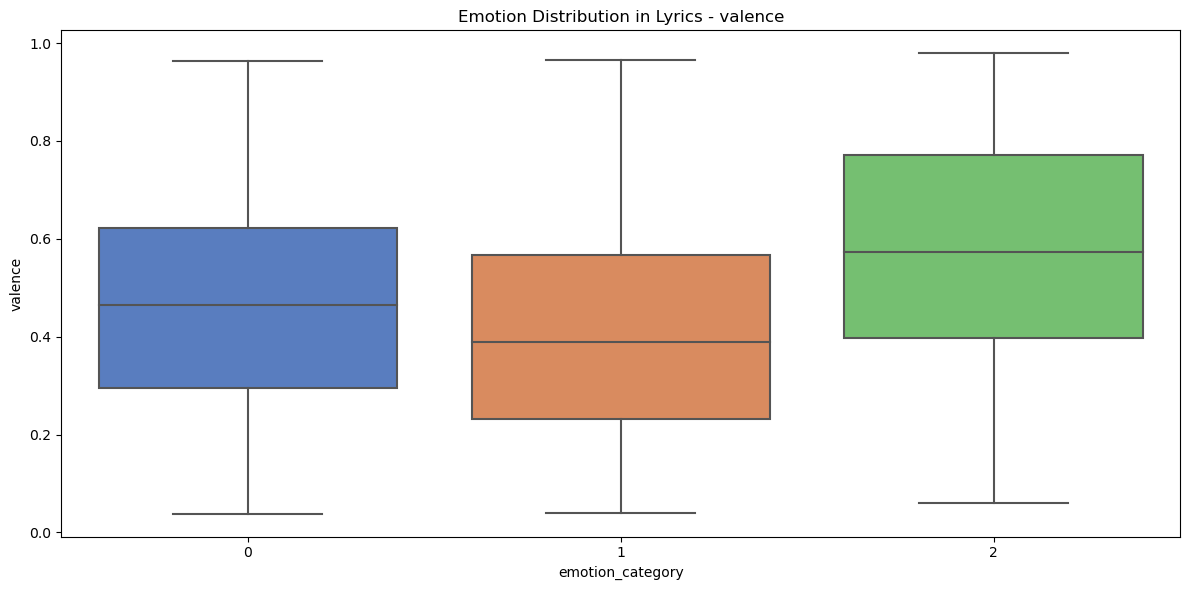

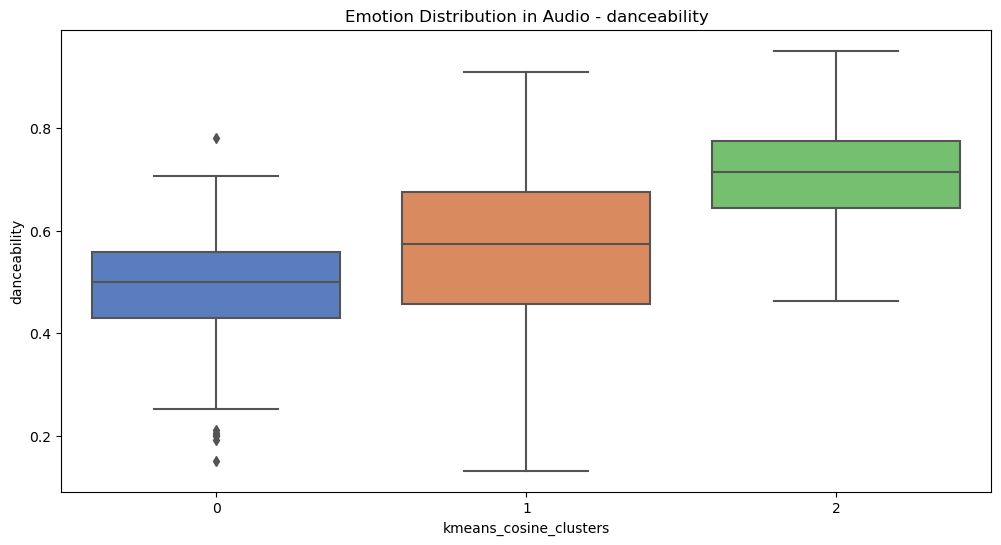

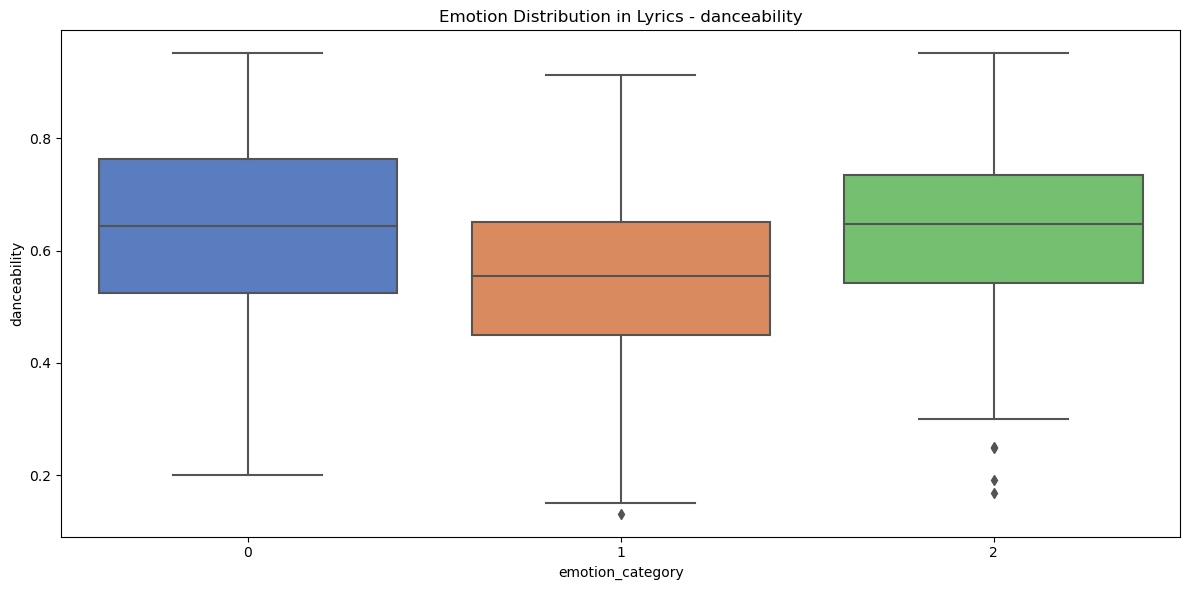

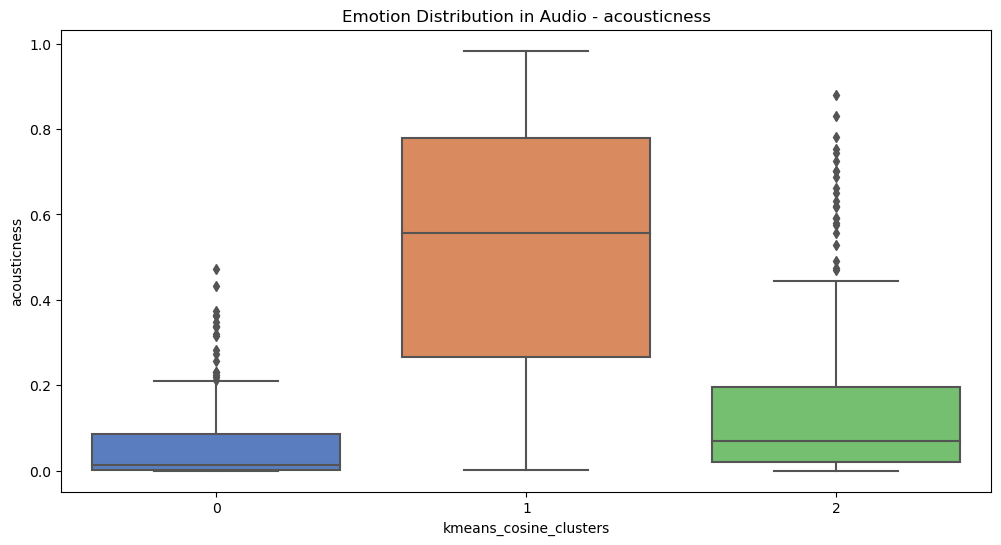

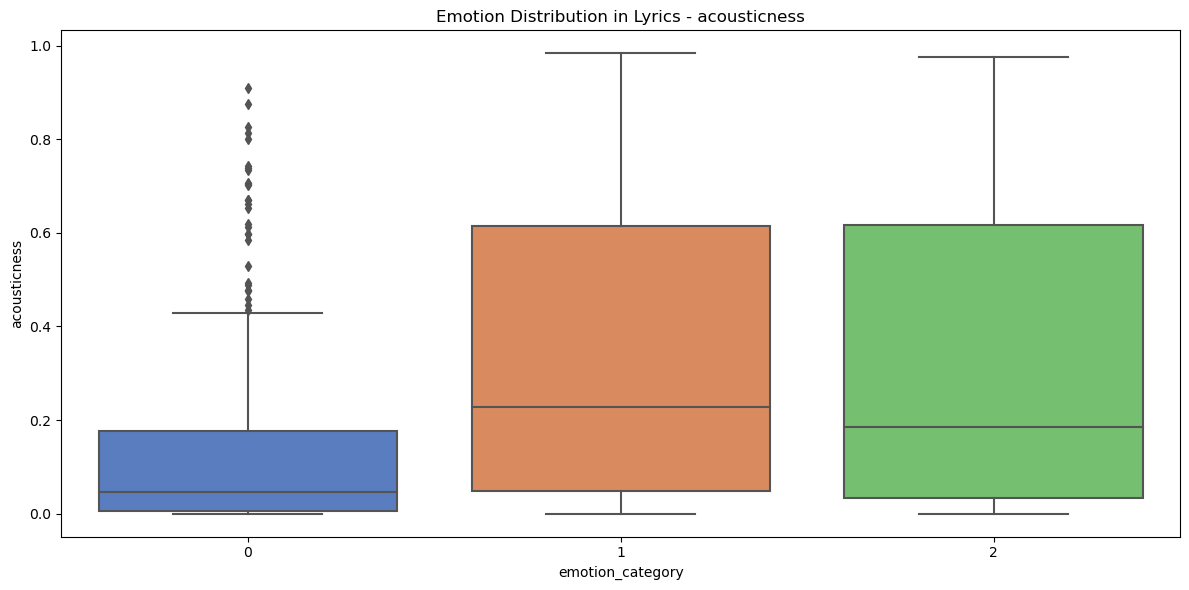

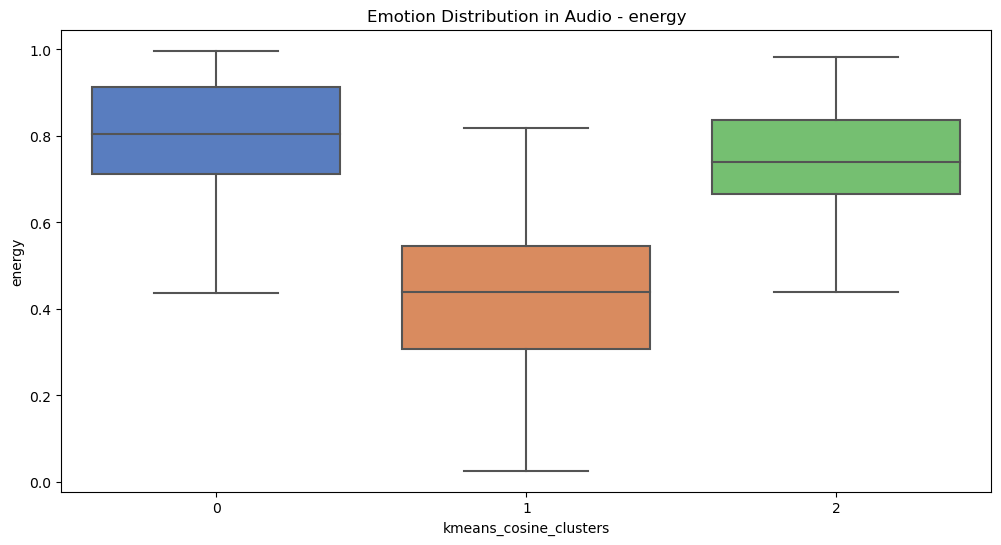

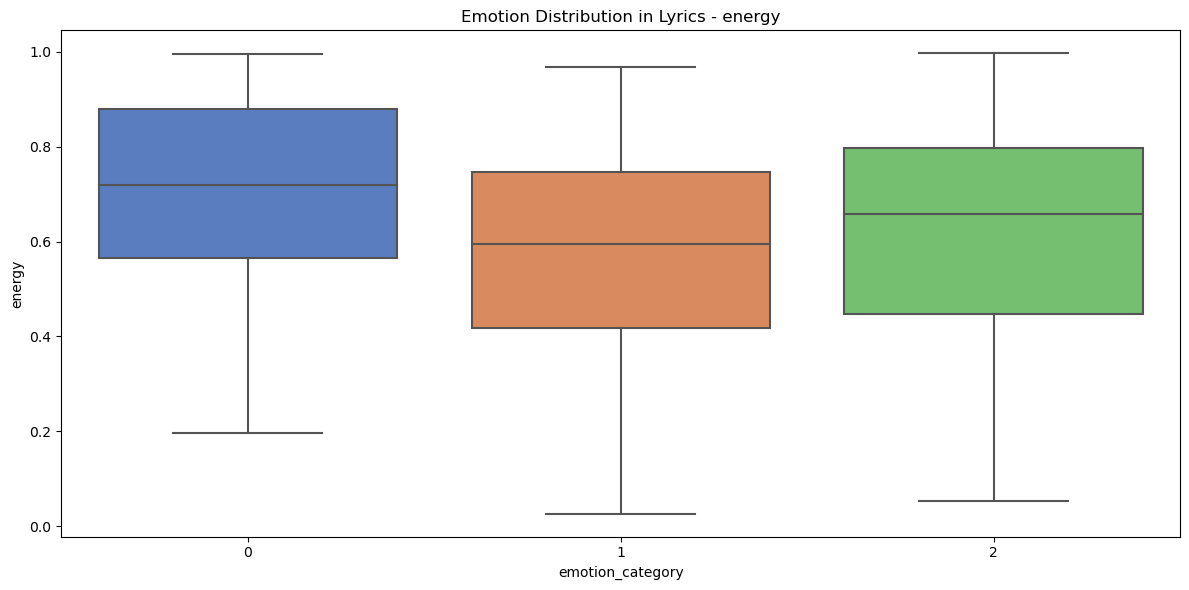

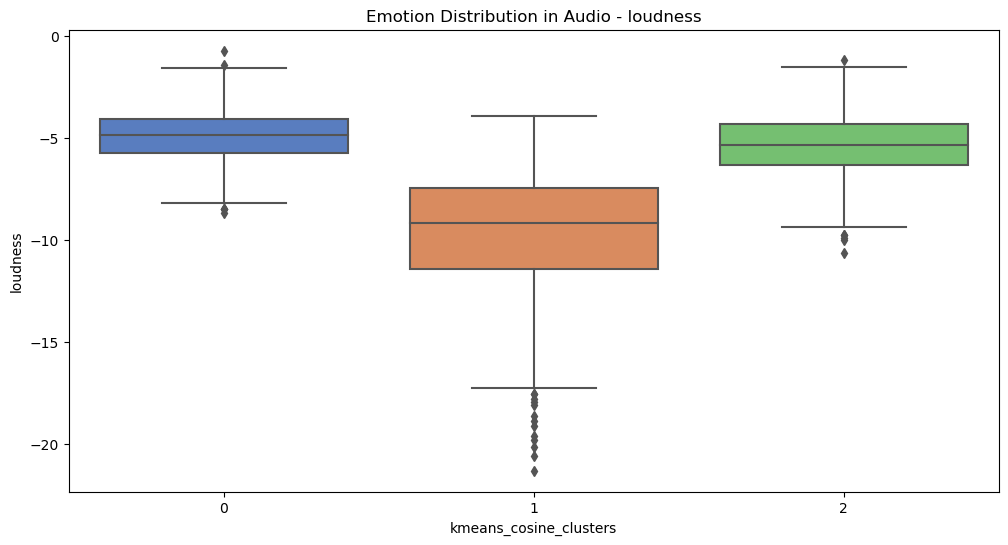

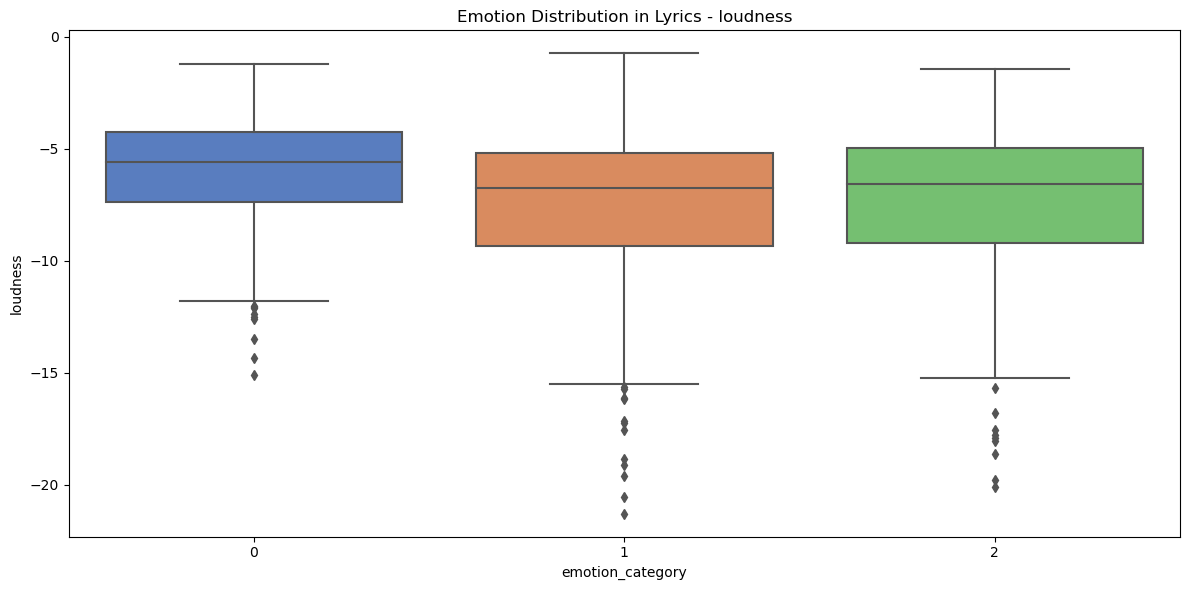

In [40]:
plt.figure(figsize=(10, 6 * len(selected_features)))

for i, feature in enumerate(selected_features, 1):
    # Plotting for 'kmeans_cosine_clusters' vs each feature
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='kmeans_cosine_clusters', y=feature, palette='muted')
    plt.title(f'Emotion Distribution in Audio - {feature}')
    
    # Plotting for 'emotion_category' vs each feature
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='emotion_category', y=feature, palette='muted')
    plt.title(f'Emotion Distribution in Lyrics - {feature}')
    
    # Adjust layout
    plt.tight_layout()

plt.show()